# Preliminary Exploratory Analysis of Flood Events

### Import Modules

In [19]:
import pandas as pd
import numpy as np

### Load Data

In [20]:
input_data_directory = '../../../../../data/meteorologia/clean'

ocorrencias = pd.read_csv(f'{input_data_directory}/adm_cor_comando/ocorrencias.csv')
pops = pd.read_csv('../../../data/raw/adm_cor_comando/pops.csv', index_col=0)

### Preprocessing `ocorrencias`

In [21]:
# Convert datetime data type fields
ocorrencias['data_inicio'] = pd.to_datetime(ocorrencias['data_inicio'])
ocorrencias['data_fim'] = pd.to_datetime(ocorrencias['data_fim'])

# Map event type
ocorrencias['tipo'] = ocorrencias['id_pop'].map(pops.set_index('id')['titulo'])

### Filter flood events

In [22]:
flood_types = [
    "Bolsão d'água em via",
    'Alagamento',
    'Alagamentos e enchentes',
    'Enchente',
    "Lâmina d'água"
]

ocorrencias = ocorrencias[ocorrencias['tipo'].isin(flood_types)]
ocorrencias['tipo'] = ocorrencias['tipo'].replace('Alagamentos e enchentes', 'Alagamento').replace('Enchente', 'Alagamento')

---

# Data Visualization of Flood Events in Rio de Janeiro

This Jupyter Notebook implements a comprehensive data visualization plan to analyze flood events in Rio de Janeiro, using the dataset loaded into the `ocorrencias` variable. We will use Plotly for creating interactive and informative visualizations.

## 1. Data Overview & Preprocessing

In this section, we will load the necessary libraries, inspect the dataset, and perform data cleaning and feature engineering steps as outlined in the plan.

In [23]:
# !pip install wordcloud
# !pip install nltk
# !pip install cartopy
# !pip install geopandas
# !pip install rasterio
# !pip install contextily

import pandas as pd
# import plotly.express as px
# import plotly.graph_objects as go
# from plotly.subplots import make_subplots
import numpy as np
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# print("First 5 rows of the DataFrame:")
# print(ocorrencias.head())
# print("\nDataFrame Info:")
# print(ocorrencias.info())

### Data Cleaning & Transformation

- Convert “data_inicio” and “data_fim” to datetime objects.
- Compute event duration (in minutes) as a new column.
- Derive additional temporal features (hour, day of week, month, season).
- Handle missing values in `prazo_num` (filling with 0 for now as example).

In [24]:
ocorrencias['duration_seconds'] = (ocorrencias['data_fim'] - ocorrencias['data_inicio']).dt.total_seconds()
ocorrencias['duration_minutes'] = ocorrencias['duration_seconds'] / 60

ocorrencias['hour_start'] = ocorrencias['data_inicio'].dt.hour
ocorrencias['day_of_week'] = ocorrencias['data_inicio'].dt.day_name()
ocorrencias['month'] = ocorrencias['data_inicio'].dt.month_name()
ocorrencias['month_num'] = ocorrencias['data_inicio'].dt.month
ocorrencias['year'] = ocorrencias['data_inicio'].dt.year
ocorrencias['day_of_month'] = ocorrencias['data_inicio'].dt.day
ocorrencias['date'] = pd.to_datetime(ocorrencias['data_inicio'].dt.date)

# Define seasons (for Rio de Janeiro - approximate)
def get_season(month):
    if month in [12, 1, 2]:
        return 'Summer'
    elif month in [3, 4, 5]:
        return 'Autumn'
    elif month in [6, 7, 8]:
        return 'Winter'
    else:
        return 'Spring'

ocorrencias['season'] = ocorrencias['month_num'].apply(get_season)

# Handle missing values in 'prazo_num' - Fill with 0 for demonstration
ocorrencias['prazo_num'] = ocorrencias['prazo_num'].fillna(0)

print("\nDataFrame after preprocessing:")
display(ocorrencias.head())


DataFrame after preprocessing:


,id_pop,id_evento,bairro,data_inicio,data_fim,prazo,descricao,gravidade,latitude,longitude,...,duration_seconds,duration_minutes,hour_start,day_of_week,month,month_num,year,day_of_month,date,season
829,5.0,66955,Caju,2021-10-15 22:11:46+00:00,2021-10-15 22:16:00+00:00,Curto,"Av. rio de janeiro, 675 - caju",Baixo,-22.891448,-43.214630,...,254.0,4.233333,22,Friday,October,10,2021,15,2021-10-15,Spring
830,5.0,67278,Lagoa,2021-10-24 16:34:17+00:00,2021-10-24 19:52:44+00:00,Curto,"Av. epitácio pessoa, alt. r. garcia d'avila- l...",Baixo,-22.980942,-43.208720,...,11907.0,198.450000,16,Sunday,October,10,2021,24,2021-10-24,Spring
831,5.0,67280,Lagoa,2021-10-24 16:45:02+00:00,2021-10-24 18:19:05+00:00,Curto,"Av. borges de medeiros, alt. r. batista da cos...",Baixo,-22.965323,-43.215881,...,5643.0,94.050000,16,Sunday,October,10,2021,24,2021-10-24,Spring
832,5.0,67279,Lagoa,2021-10-24 16:39:46+00:00,2021-10-24 17:50:16+00:00,Curto,"Viaduto saint hilaire, alt. alça de acesso av....",Baixo,-22.961056,-43.204173,...,4230.0,70.500000,16,Sunday,October,10,2021,24,2021-10-24,Spring
833,5.0,66613,Penha,2021-10-03 17:29:02+00:00,2021-10-03 18:15:23+00:00,Curto,Rua ibiapina - alt. r. monsenhor alves rocha -...,Baixo,-22.841611,-43.276258,...,2781.0,46.350000,17,Sunday,October,10,2021,3,2021-10-03,Spring


### Data Segmentation

- Create subsets for each event type.

In [25]:
bolsao_dagua = ocorrencias[ocorrencias['tipo'] == "Bolsão d'água em via"]
alagamentos = ocorrencias[ocorrencias['tipo'] == "Alagamento"]
lamina_dagua = ocorrencias[ocorrencias['tipo'] == "Lâmina d'água"]

print("\nNumber of 'Bolsão d'água em via' events:", len(bolsao_dagua))
print("Number of 'Alagamento' events:", len(alagamentos))
print("Number of 'Lâmina d'água' events:", len(lamina_dagua))


Number of 'Bolsão d'água em via' events: 4217
Number of 'Alagamento' events: 466
Number of 'Lâmina d'água' events: 185


## 2. Descriptive Statistics & Summary Tables

### Overall Summary Table

- Total number of events, average duration, and overall counts per “gravidade” and “status”.
- Table of descriptive statistics for event durations.

In [26]:
total_events = len(ocorrencias)
avg_duration_minutes = ocorrencias['duration_minutes'].mean()

gravidade_counts = ocorrencias['gravidade'].value_counts().to_frame()
status_counts = ocorrencias['status'].value_counts().to_frame()

duration_stats = ocorrencias['duration_minutes'].describe().to_frame()

print("### Overall Summary")
print(f"Total Number of Events: {total_events}")
print(f"Average Event Duration: {avg_duration_minutes:.2f} minutes")
print("\nCounts by Gravidade:\n")
display(gravidade_counts)
print("\nCounts by Status:\n")
display(status_counts)
print("\nDescriptive Statistics for Event Duration (minutes):\n")
display(duration_stats)

### Overall Summary
Total Number of Events: 4868
Average Event Duration: 243.20 minutes

Counts by Gravidade:



,count
gravidade,
Baixo,4176
Medio,391
Normal,173
Alto,99
Critico,18
Média,7
Sem classificação,2
Sem_classificacao,2



Counts by Status:



,count
status,
Fechado,4864
Aberto,4



Descriptive Statistics for Event Duration (minutes):



,duration_minutes
count,4868.000000
mean,243.201465
std,512.119420
min,0.616667
25%,61.937500
50%,126.966667
75%,238.829167
max,15122.066667


### Event Type Breakdown

- Table showing counts and percentages of each event type.
- Pivot table: rows = “bairro”, columns = “tipo”, values = count of events.

In [27]:
event_type_counts = ocorrencias['tipo'].value_counts().to_frame()
event_type_percentages = (ocorrencias['tipo'].value_counts(normalize=True) * 100).to_frame()

print("\n### Event Type Breakdown")
print("\nEvent Type Counts:\n")
display(event_type_counts)
print("\nEvent Type Percentages:\n")
display(event_type_percentages.map('{:.2f}%'.format))

pivot_table_bairro_tipo = pd.pivot_table(ocorrencias, index='bairro', columns='tipo', aggfunc='size', fill_value=0)
print("\nPivot Table (Bairro vs Tipo):\n")
display(pivot_table_bairro_tipo)


### Event Type Breakdown

Event Type Counts:



,count
tipo,
Bolsão d'água em via,4217
Alagamento,466
Lâmina d'água,185



Event Type Percentages:



,proportion
tipo,
Bolsão d'água em via,86.63%
Alagamento,9.57%
Lâmina d'água,3.80%



Pivot Table (Bairro vs Tipo):



tipo,Alagamento,Bolsão d'água em via,Lâmina d'água
bairro,,,
Abolição,0,3,0
Acari,8,4,0
Alto da boa vista,1,2,0
Anchieta,2,17,0
Andaraí,2,6,0
...,...,...,...
Vila isabel,4,50,1
Vila kosmos,0,1,0
Vila militar,0,4,0


### Temporal Summaries

- Table summarizing counts per month/season and per day-of-week.
- Summary table by “prazo” category.

In [28]:
monthly_counts = ocorrencias['month'].value_counts().sort_index() # Sort by month order
seasonal_counts = ocorrencias['season'].value_counts()
day_of_week_counts = ocorrencias['day_of_week'].value_counts() # Already in day name order

prazo_counts = ocorrencias['prazo'].value_counts()

print("\n### Temporal Summaries")
print("\nMonthly Event Counts:\n")
display(monthly_counts.to_frame())
print("\nSeasonal Event Counts:\n")
display(seasonal_counts.to_frame())
print("\nDay of Week Event Counts:\n")
display(day_of_week_counts.to_frame())
print("\nPrazo Category Counts:\n")
display(prazo_counts.to_frame())


### Temporal Summaries

Monthly Event Counts:



,count
month,
April,508
August,109
December,697
February,969
January,664
July,84
June,114
March,786
May,240



Seasonal Event Counts:



,count
season,
Summer,2330
Autumn,1534
Spring,697
Winter,307



Day of Week Event Counts:



,count
day_of_week,
Monday,874
Thursday,827
Friday,807
Sunday,642
Tuesday,592
Wednesday,569
Saturday,557



Prazo Category Counts:



,count
prazo,
Curto,3025
Desconhecido,1836
Medio,5
Longo,2


## 3. Categorical & Comparative Visualizations

### Bar Charts & Stacked Bar Charts

- Compare counts of events by “tipo”, “bairro”, and “status”.
- Stacked bar chart to display breakdowns of “gravidade” within each event type.

C:\Users\Hanna\AppData\Local\Temp\ipykernel_8112\1293035473.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(x=event_type_counts.index, y=event_type_counts['count'], palette='viridis')


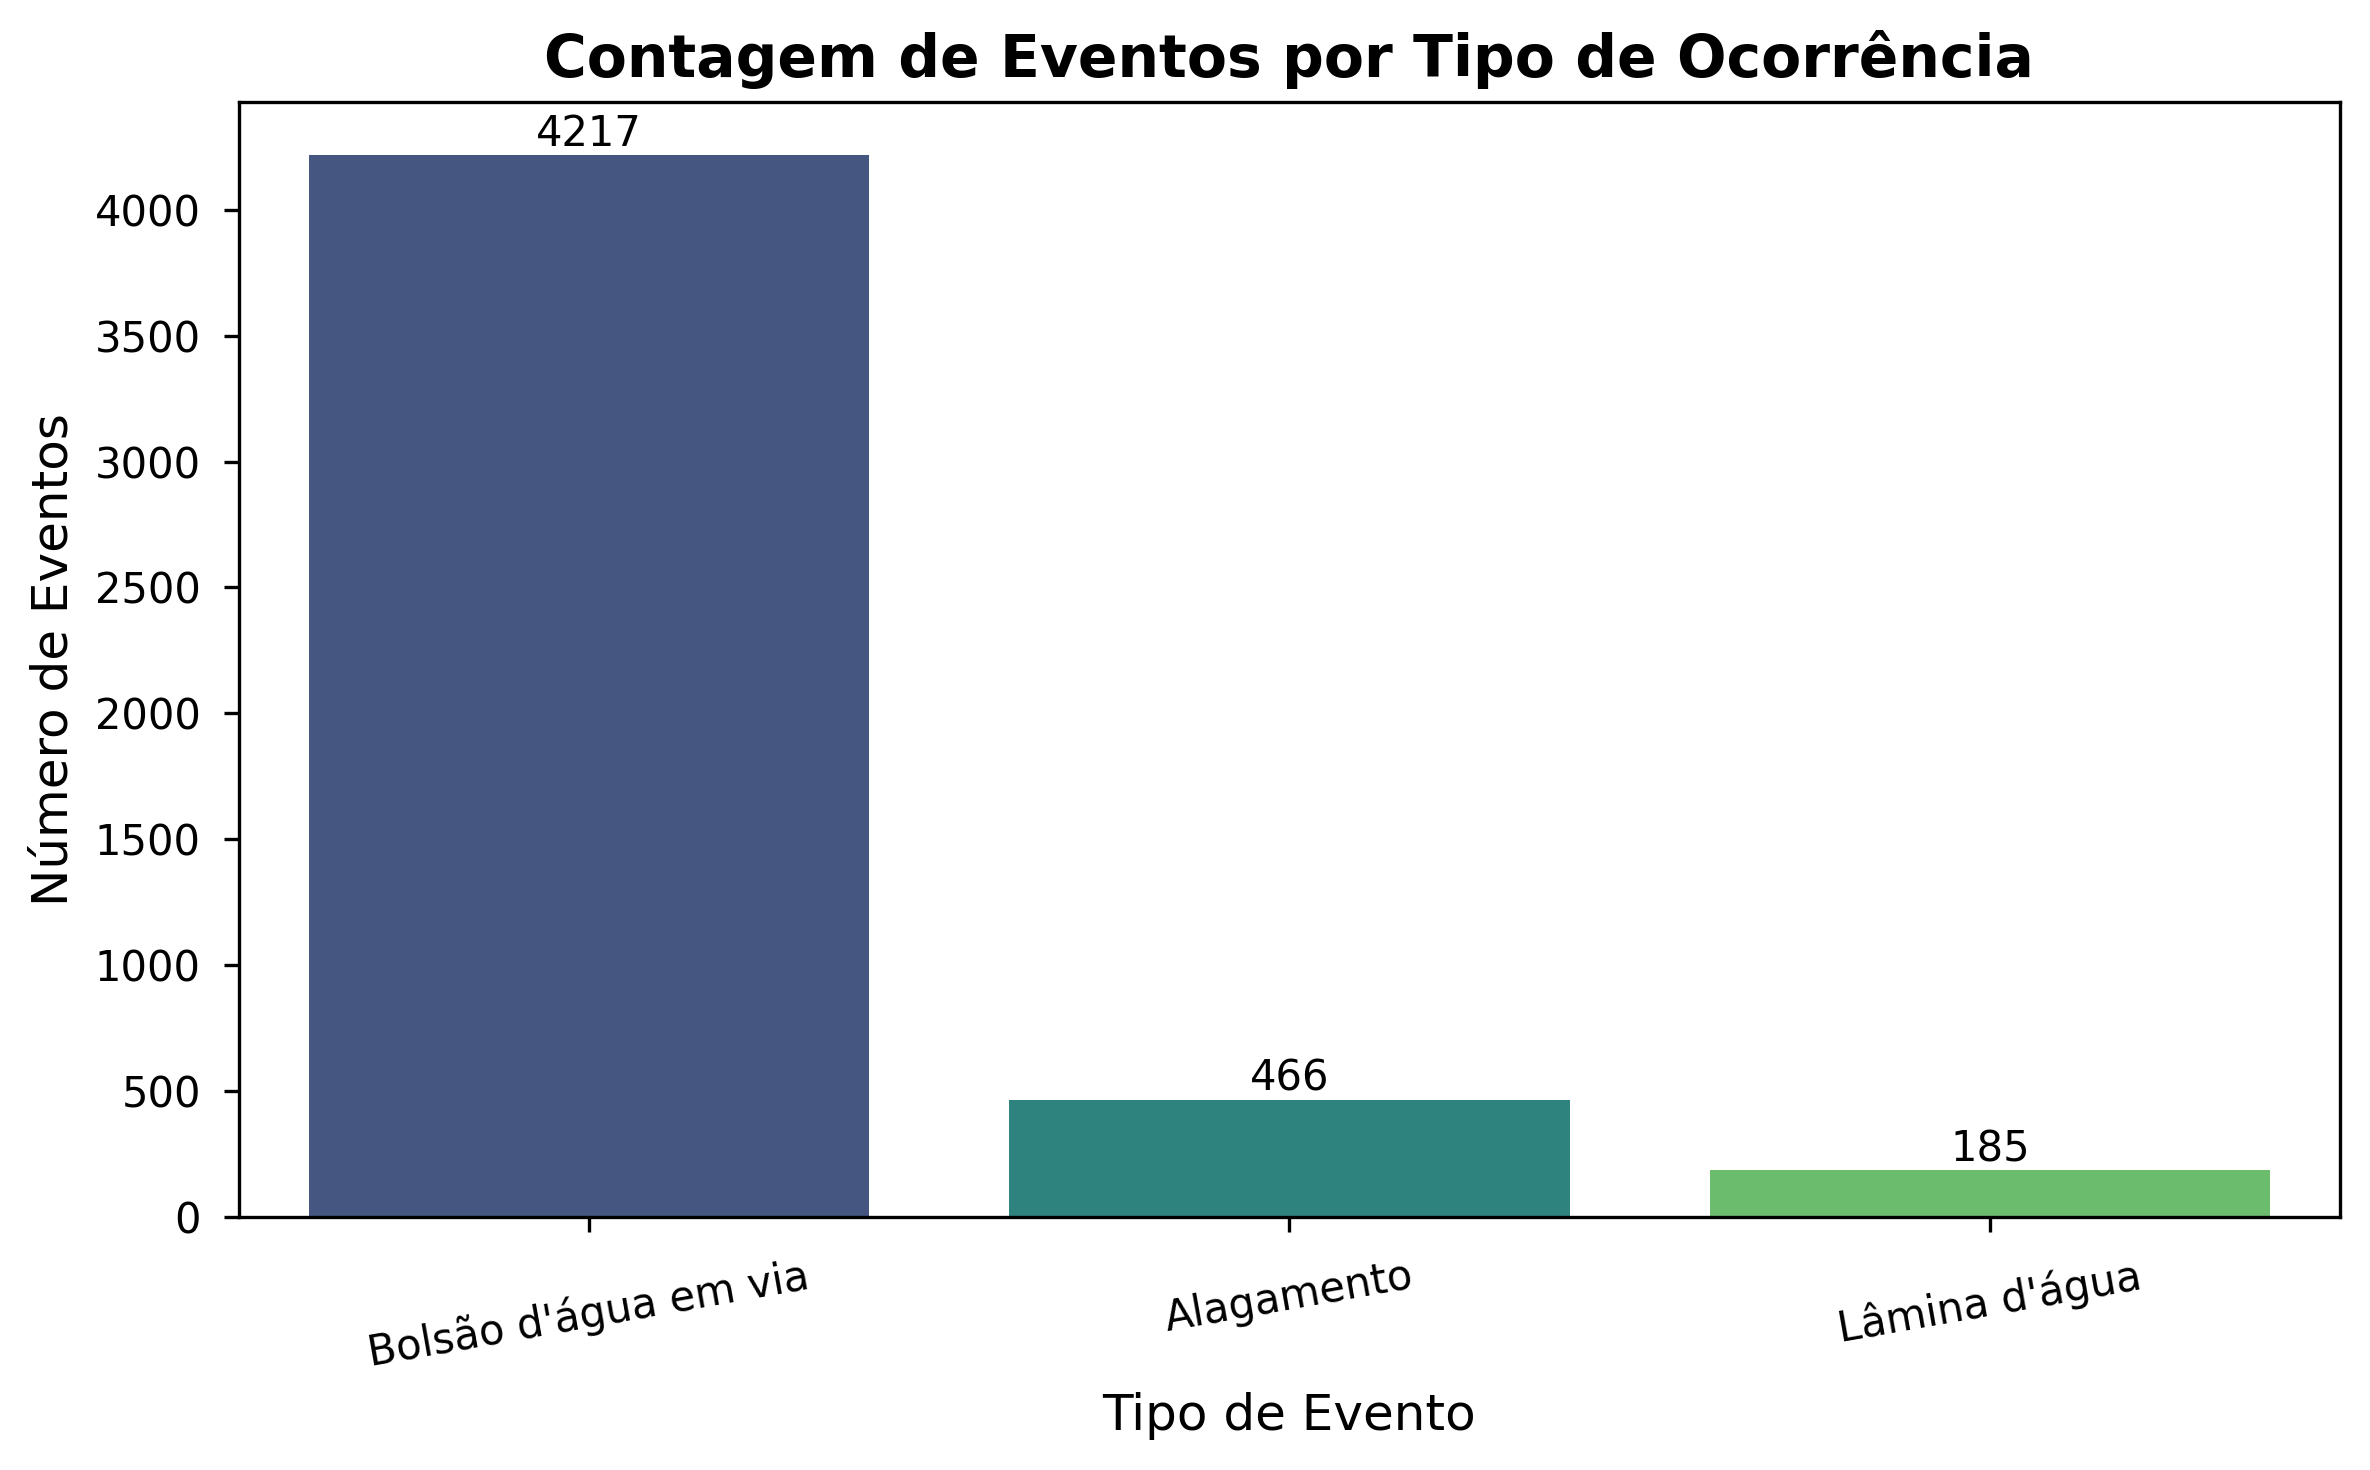

C:\Users\Hanna\AppData\Local\Temp\ipykernel_8112\1293035473.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(x=bairro_counts.index, y=bairro_counts.values, palette='plasma')


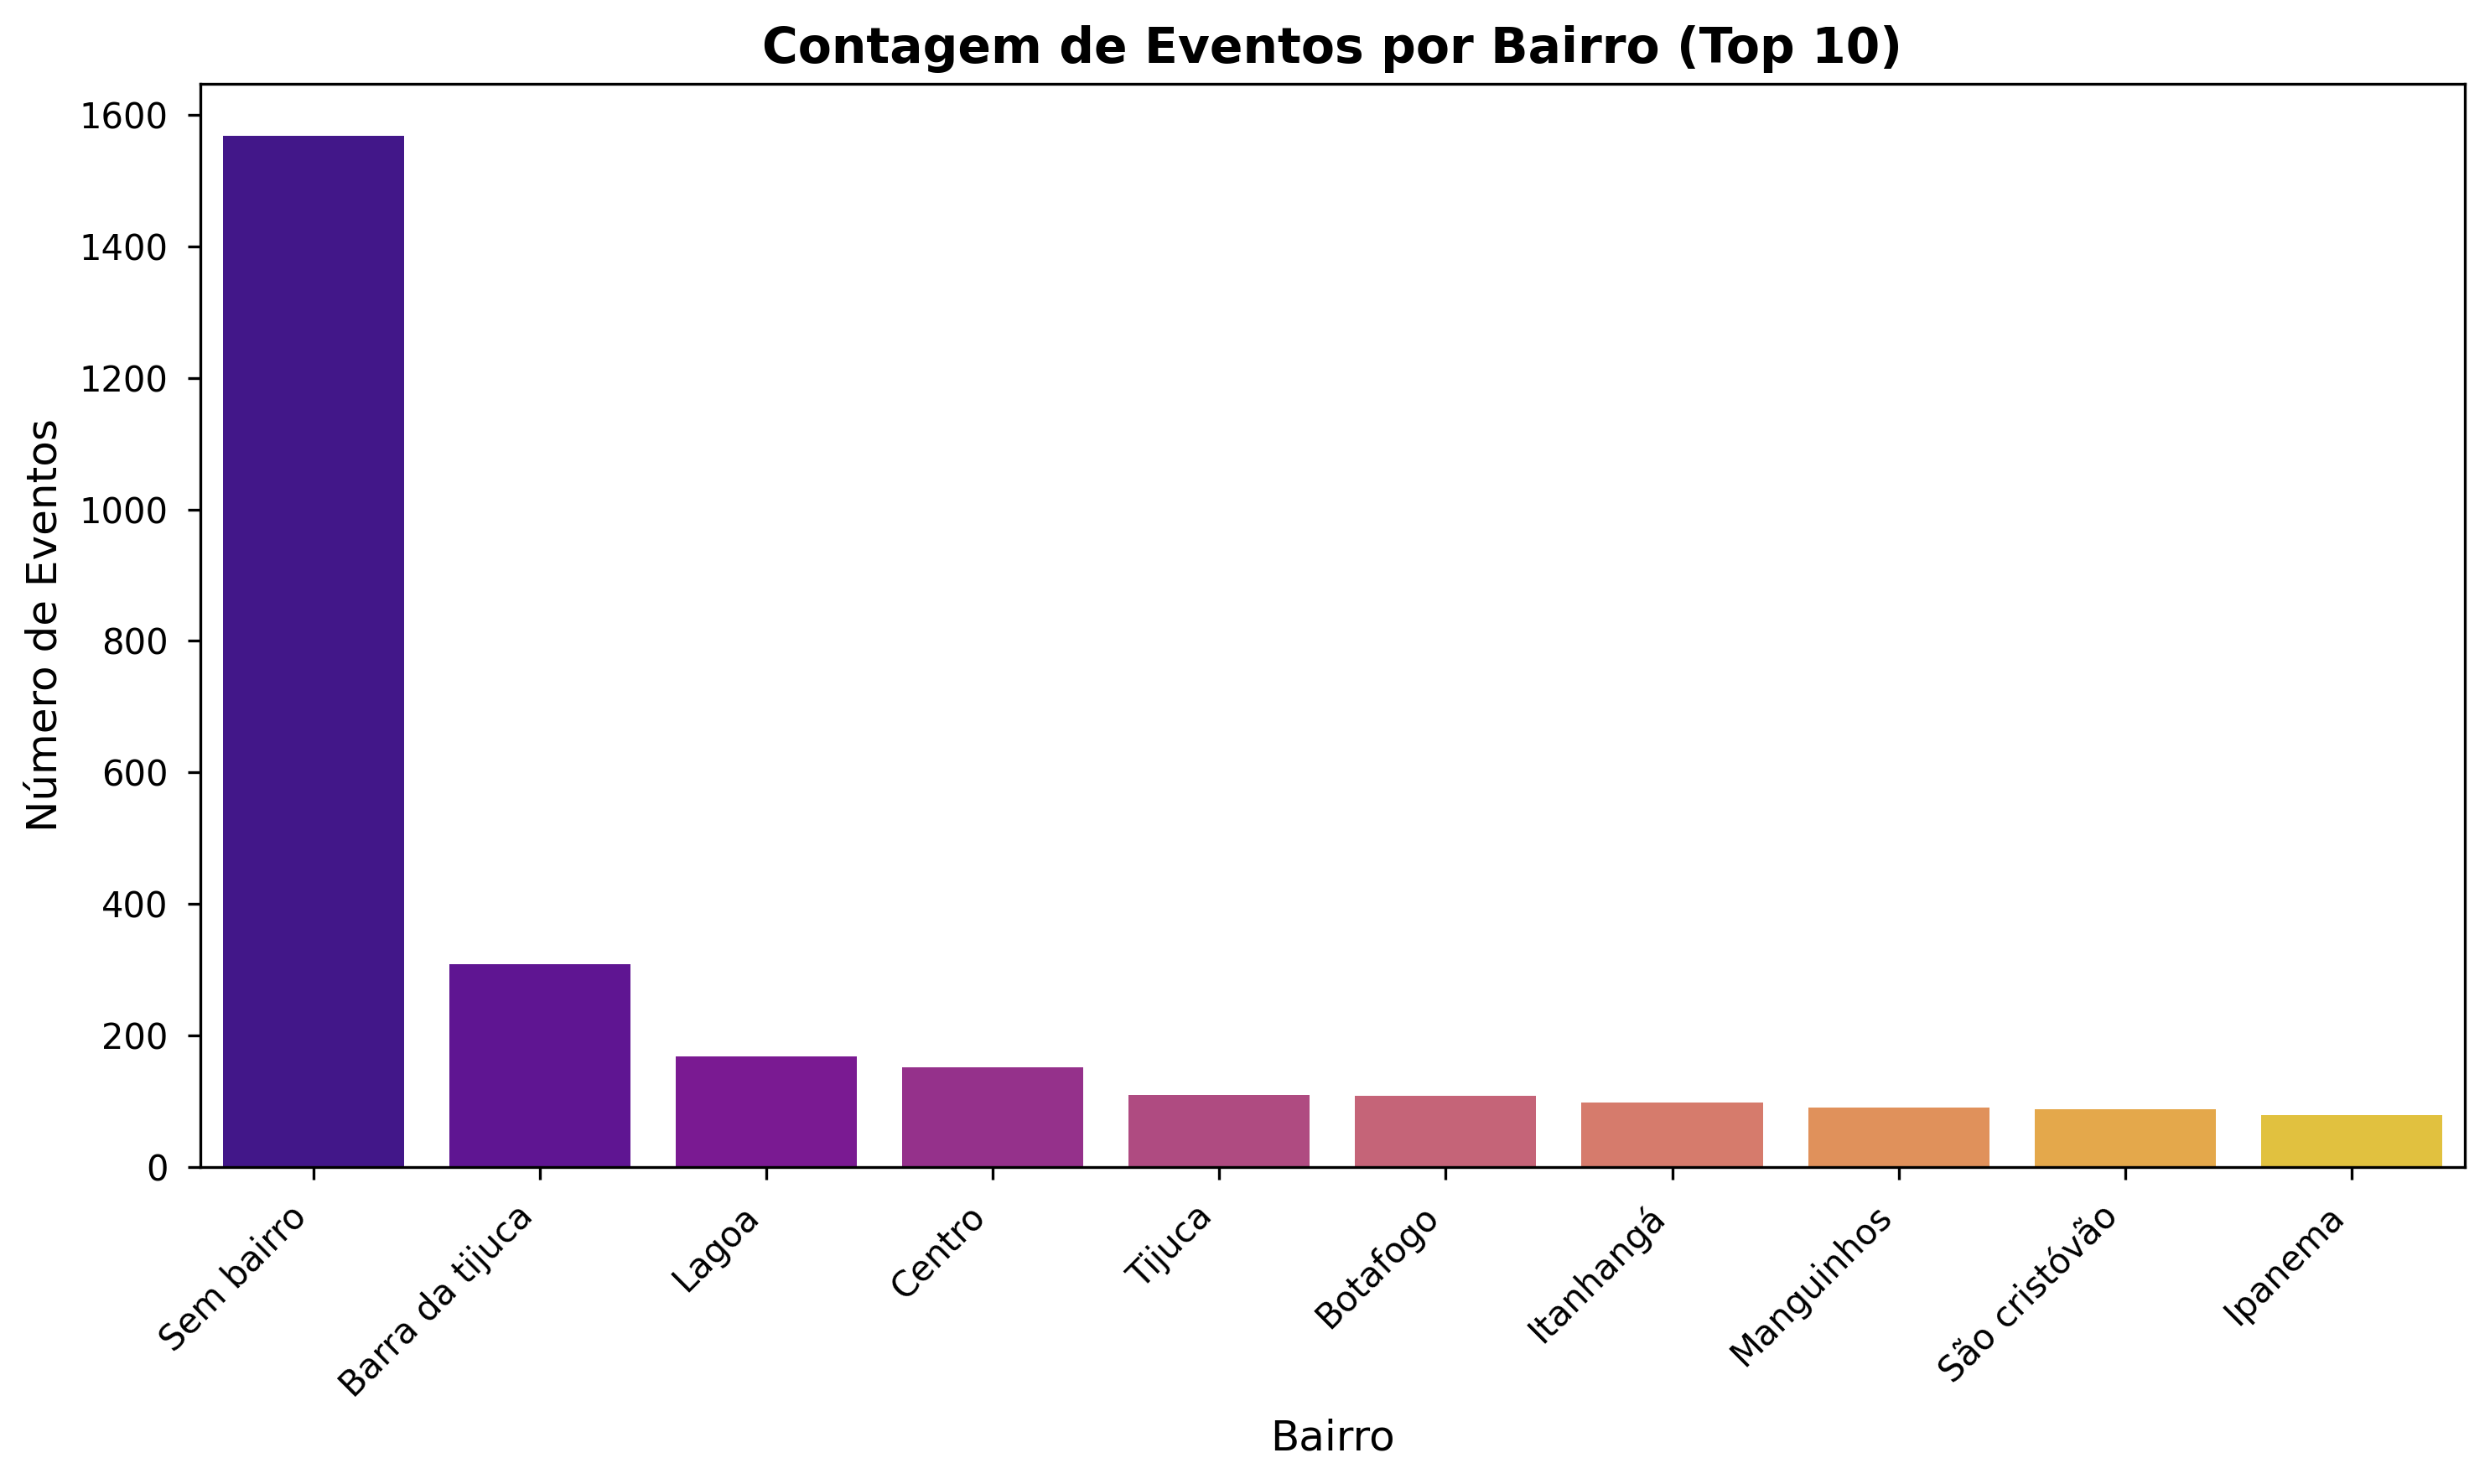

C:\Users\Hanna\AppData\Local\Temp\ipykernel_8112\1293035473.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax3 = sns.barplot(x=status_counts.index, y=status_counts['count'], palette='magma')


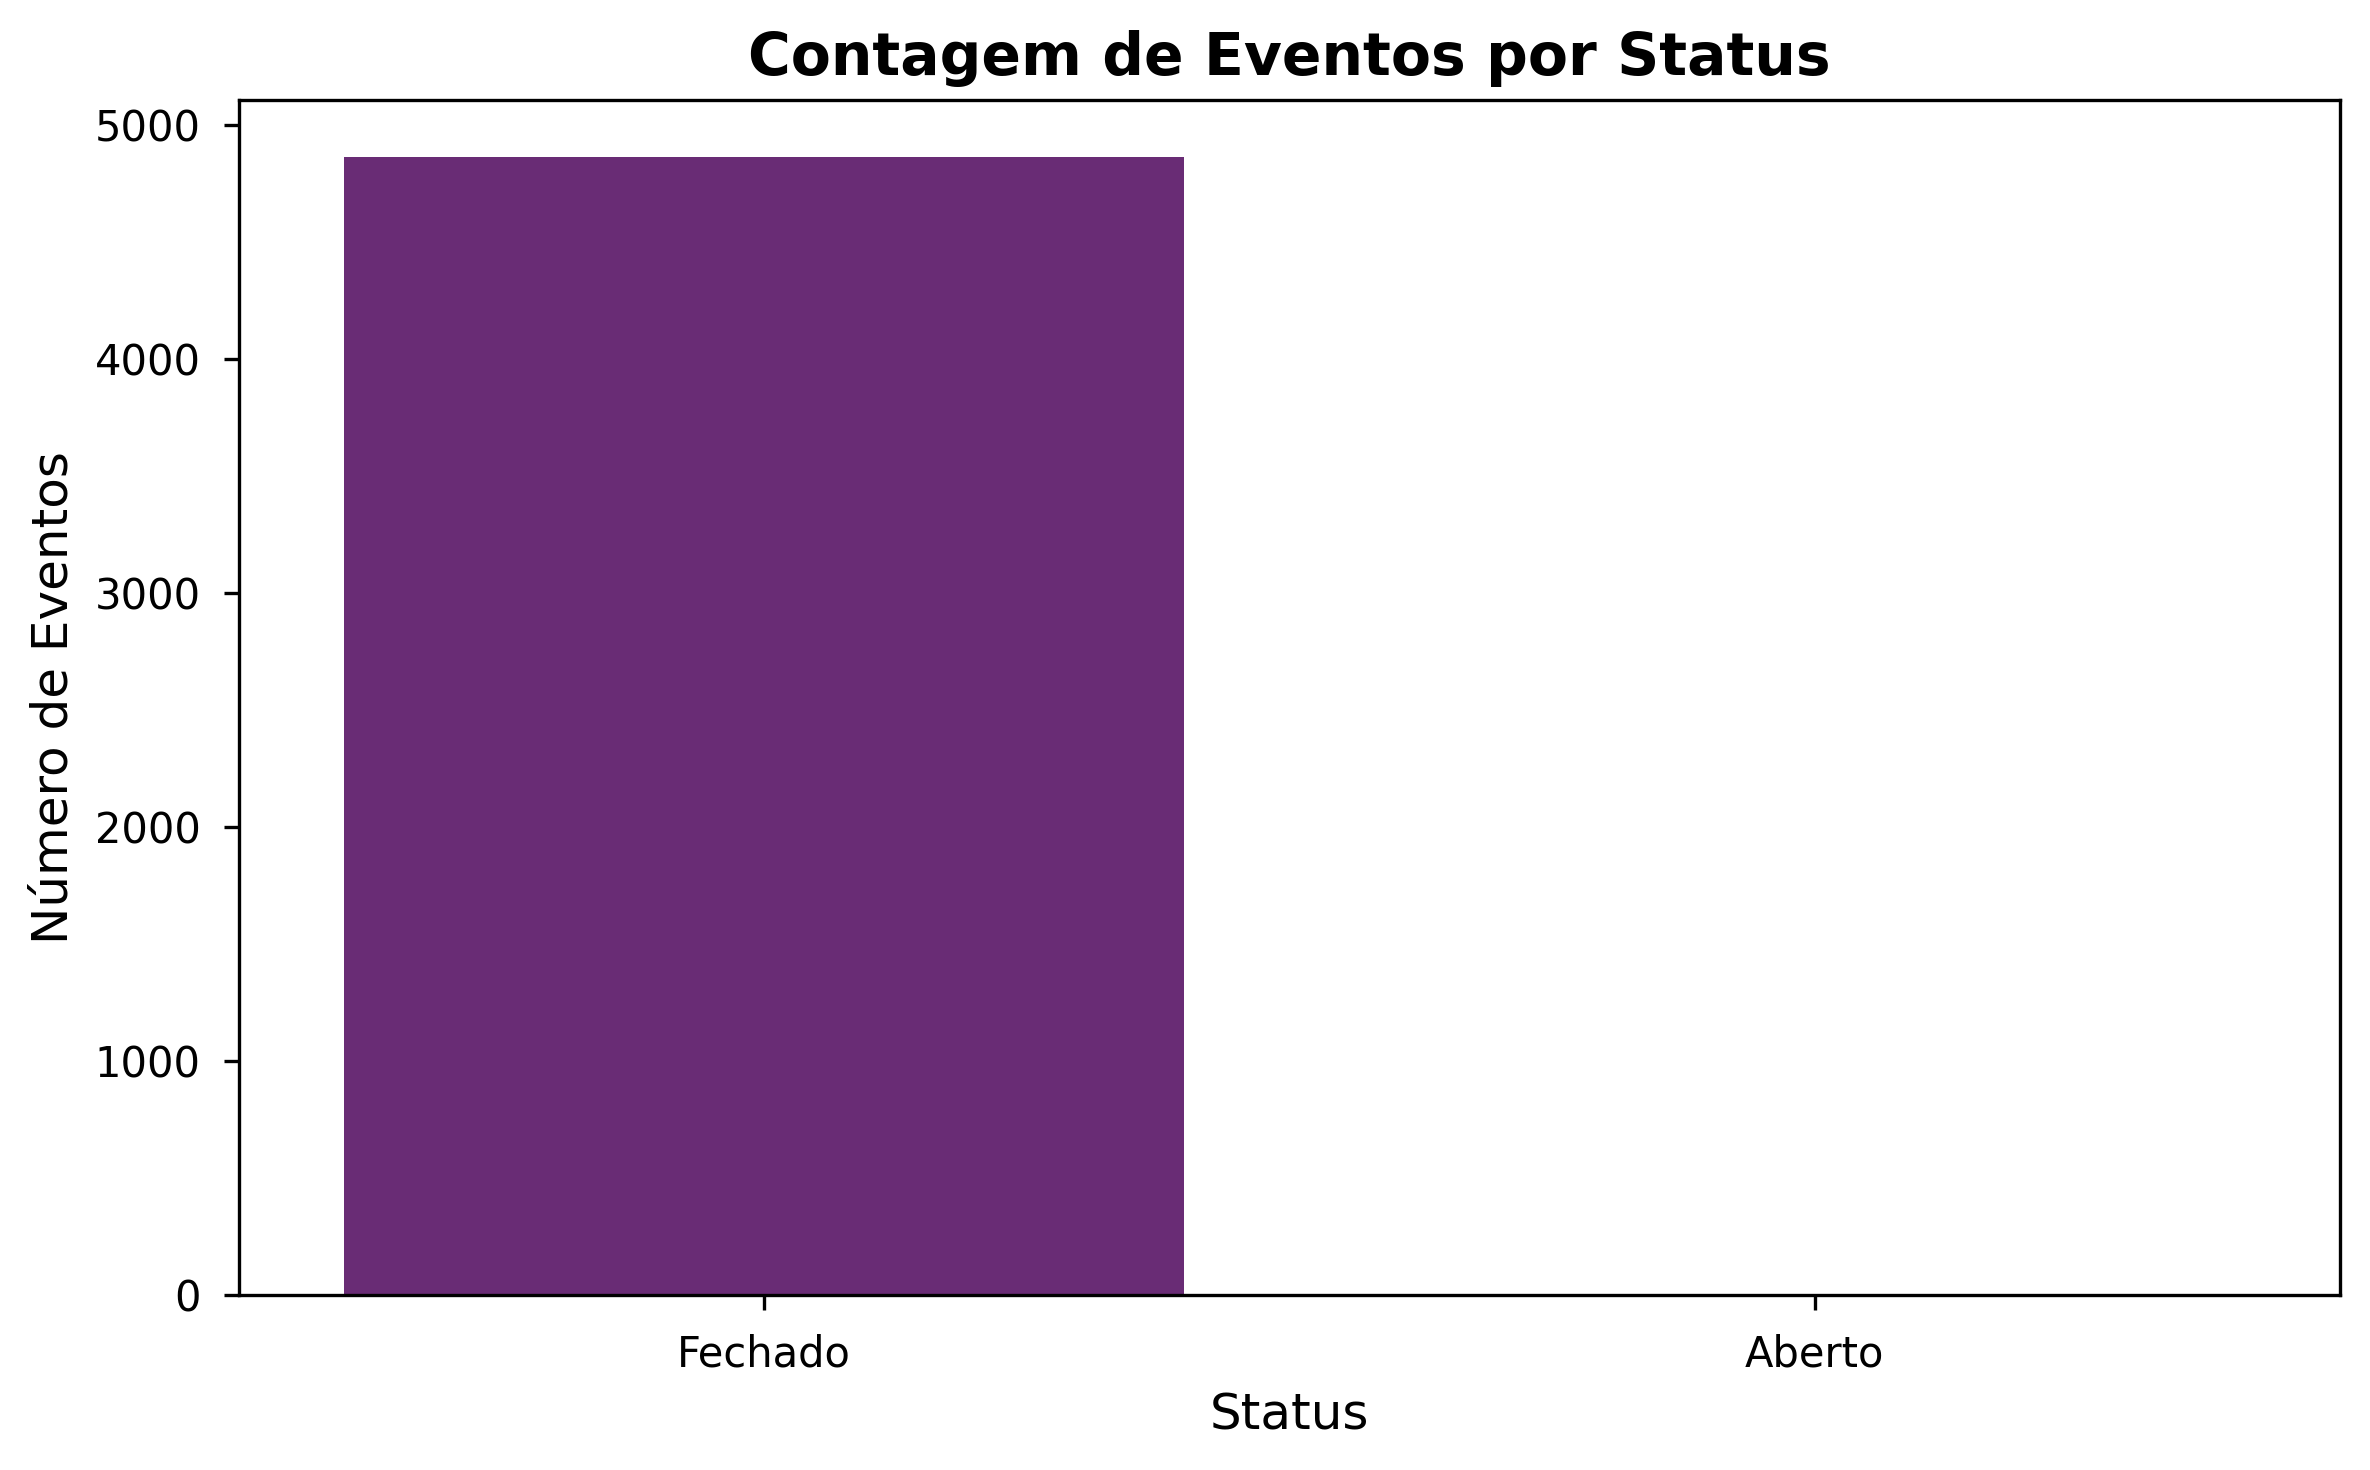

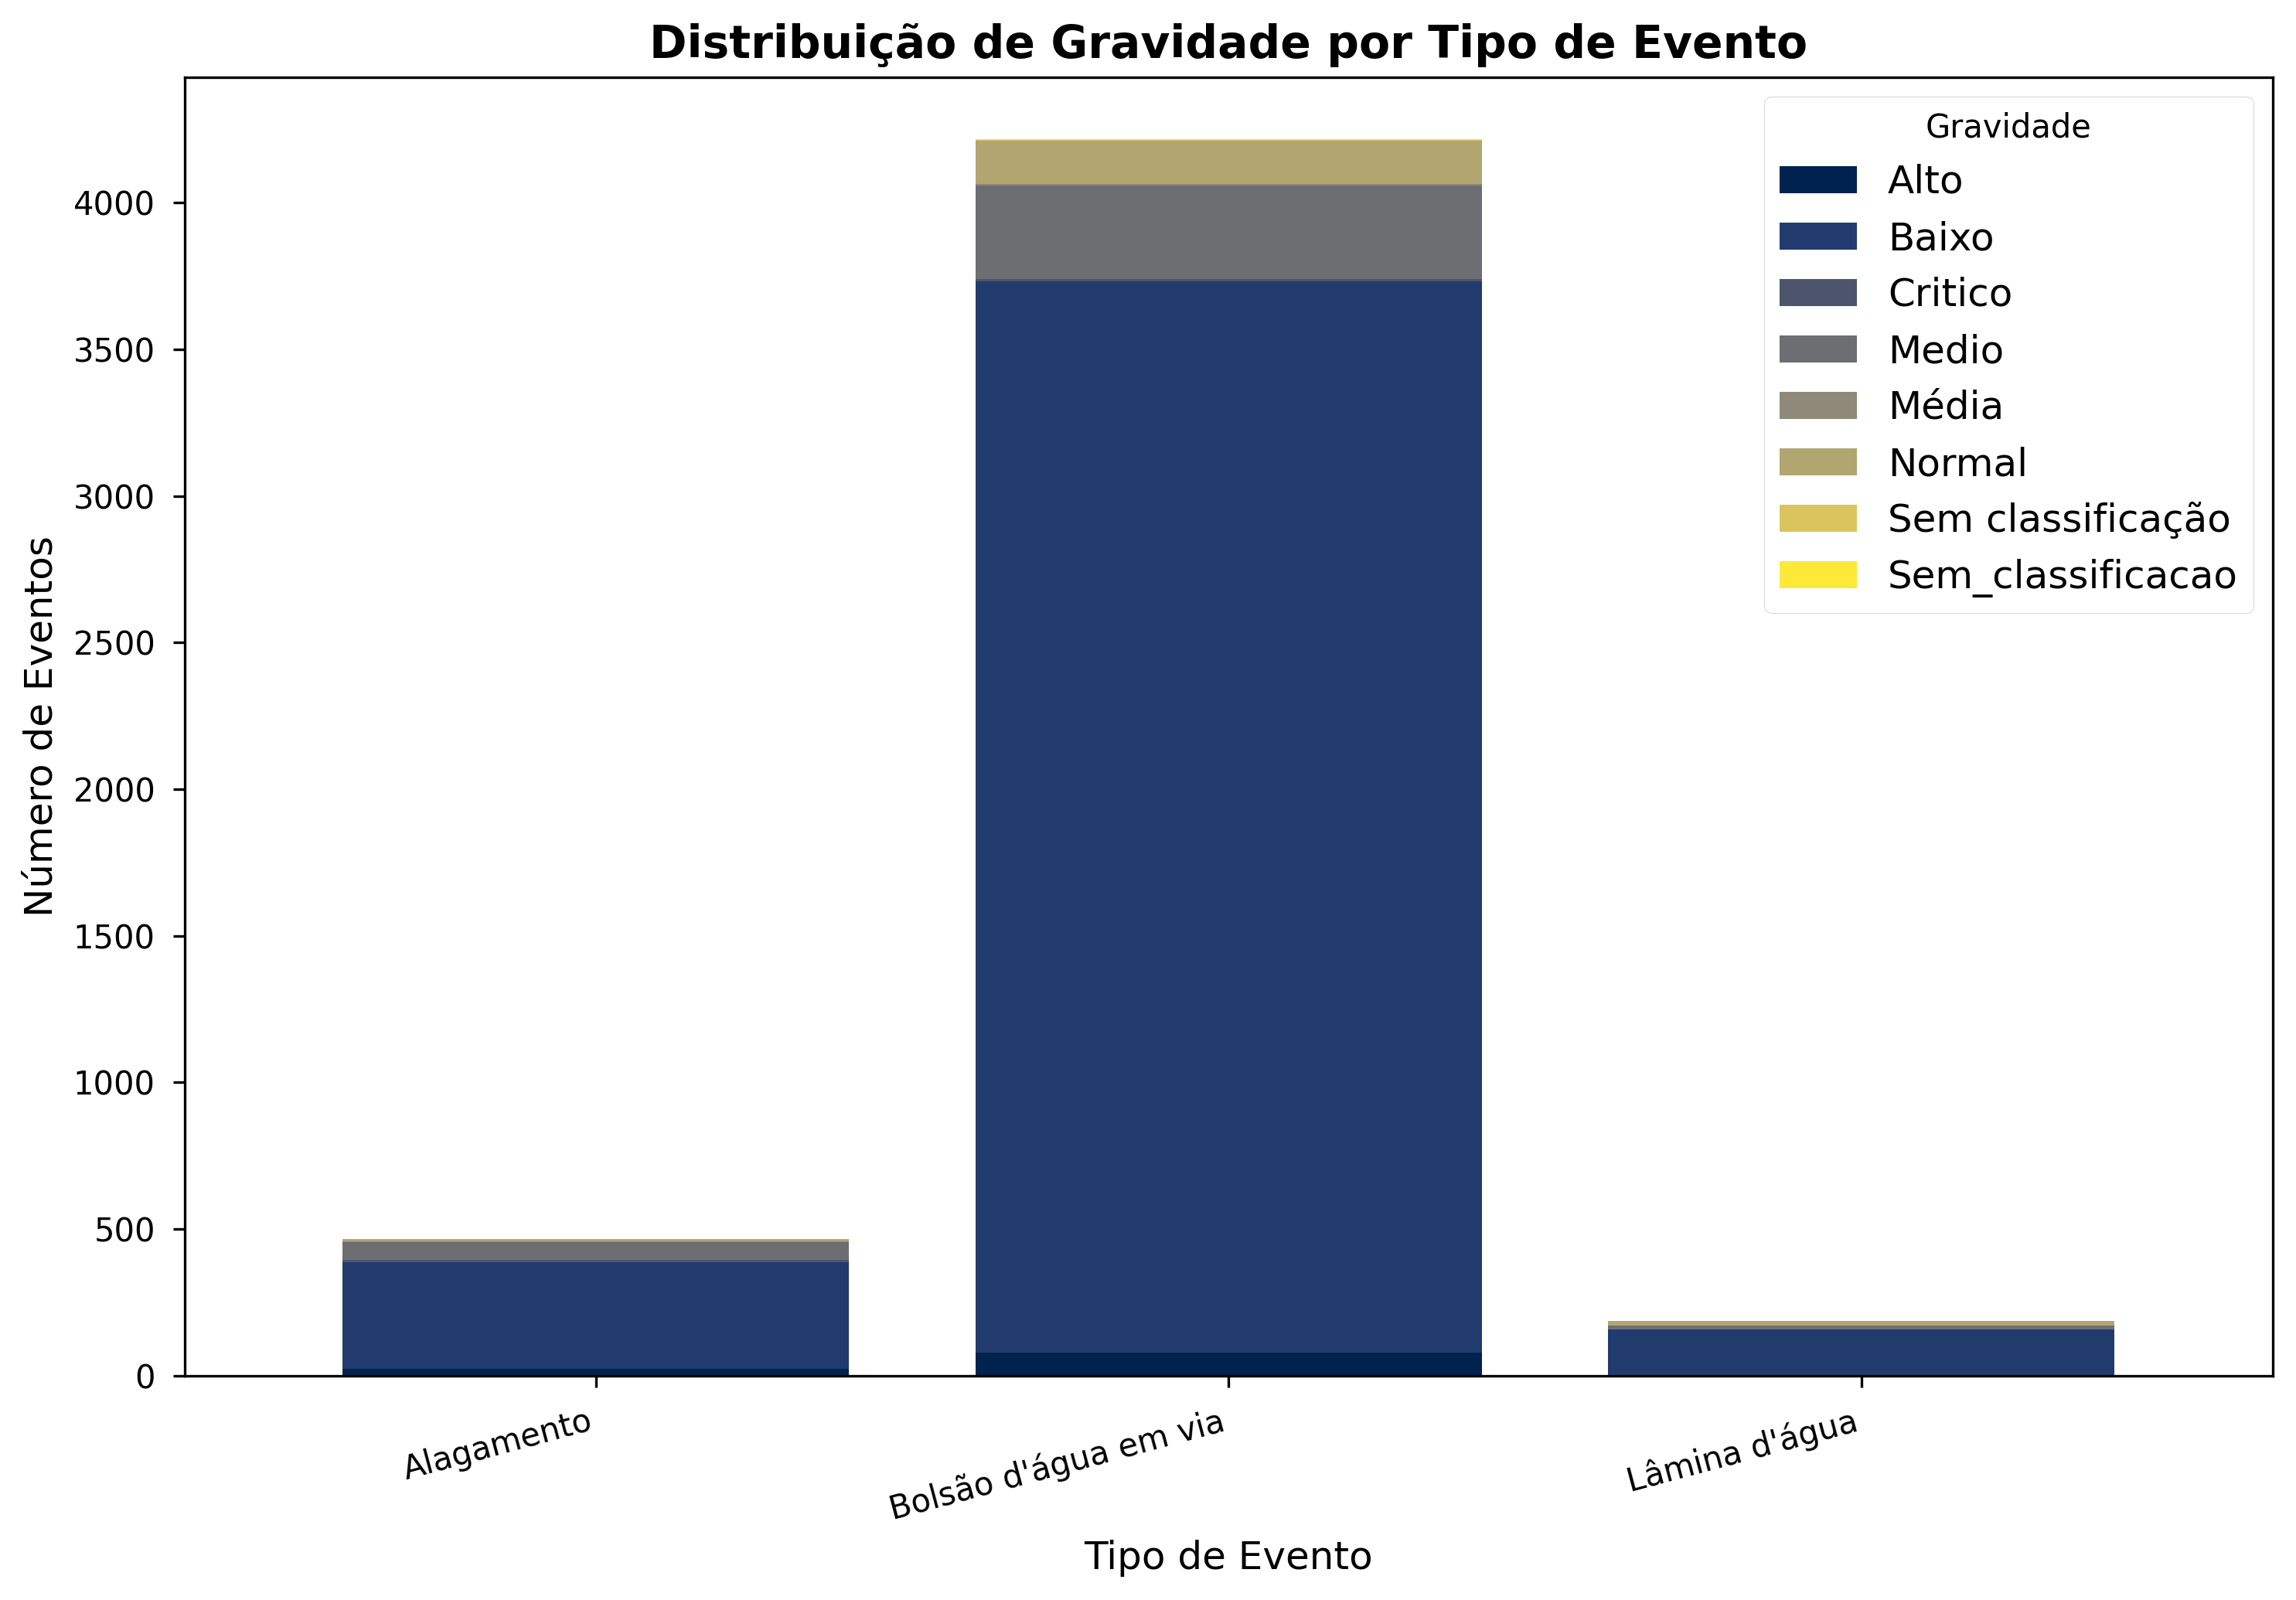

In [29]:
# Importando bibliotecas de visualização e definindo o estilo
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo para publicações acadêmicas
plt.style.use('seaborn-v0_8-paper')
plt.rcParams['figure.dpi'] = 300 # Alta resolução para as figuras

# --- Gráfico 1: Contagem de Eventos por Tipo ---
plt.figure(figsize=(8, 5))
ax1 = sns.barplot(x=event_type_counts.index, y=event_type_counts['count'], palette='viridis')
ax1.set_title('Contagem de Eventos por Tipo de Ocorrência', fontsize=14, weight='bold')
ax1.set_xlabel('Tipo de Evento', fontsize=12)
ax1.set_ylabel('Número de Eventos', fontsize=12)
ax1.tick_params(axis='x', labelsize=10)  # Increase x-axis tick label size
ax1.tick_params(axis='y', labelsize=10)  # Increase y-axis tick label size
plt.xticks(rotation=10, ha='center') # Pequena rotação para melhor leitura
# Adiciona os valores no topo das barras
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                 textcoords='offset points')
plt.tight_layout()
plt.show()


# --- Gráfico 2: Contagem de Eventos por Bairro (Top 10) ---
bairro_counts = ocorrencias['bairro'].value_counts().nlargest(10)
plt.figure(figsize=(10, 6))
ax2 = sns.barplot(x=bairro_counts.index, y=bairro_counts.values, palette='plasma')
ax2.set_title('Contagem de Eventos por Bairro (Top 10)', fontsize=14, weight='bold')
ax2.set_xlabel('Bairro', fontsize=12)
ax2.set_ylabel('Número de Eventos', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotação para evitar sobreposição dos nomes
ax2.tick_params(axis='x', labelsize=10)  # Increase x-axis tick label size
ax2.tick_params(axis='y', labelsize=10)  # Increase y-axis tick label size
plt.tight_layout()
plt.show()


# --- Gráfico 3: Contagem de Eventos por Status ---
plt.figure(figsize=(8, 5))
ax3 = sns.barplot(x=status_counts.index, y=status_counts['count'], palette='magma')
ax3.set_title('Contagem de Eventos por Status', fontsize=14, weight='bold')
ax3.set_xlabel('Status', fontsize=12)
ax3.set_ylabel('Número de Eventos', fontsize=12)
ax3.tick_params(axis='x', labelsize=10)  # Increase x-axis tick label size
ax3.tick_params(axis='y', labelsize=10)  # Increase y-axis tick label size
plt.tight_layout()
plt.show()


# --- Gráfico 4: Gráfico de Barras Empilhadas (Gravidade por Tipo de Evento) ---
gravidade_tipo_counts = ocorrencias.groupby(['tipo', 'gravidade']).size().unstack(fill_value=0)
ax4 = gravidade_tipo_counts.plot(kind='bar', stacked=True, figsize=(10, 7),
                                 colormap='cividis', width=0.8)
ax4.set_title('Distribuição de Gravidade por Tipo de Evento', fontsize=14, weight='bold')
ax4.set_xlabel('Tipo de Evento', fontsize=12)
ax4.set_ylabel('Número de Eventos', fontsize=12)
ax4.tick_params(axis='x', labelsize=10)  # Increase x-axis tick label size
ax4.tick_params(axis='y', labelsize=10)  # Increase y-axis tick label size
plt.xticks(rotation=15, ha='right')
ax4.legend(title='Gravidade', fontsize=12)
plt.tight_layout()
plt.show()

### Boxplots

- Distribution of event durations per event type to spot outliers and compare medians.
- Boxplots of duration by bairro if sample sizes allow.

C:\Users\Hanna\AppData\Local\Temp\ipykernel_8112\1996072773.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.boxplot(data=ocorrencias_filtrado, x='tipo', y='duration_minutes', palette='viridis')
C:\Users\Hanna\AppData\Local\Temp\ipykernel_8112\1996072773.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=10, ha='center')


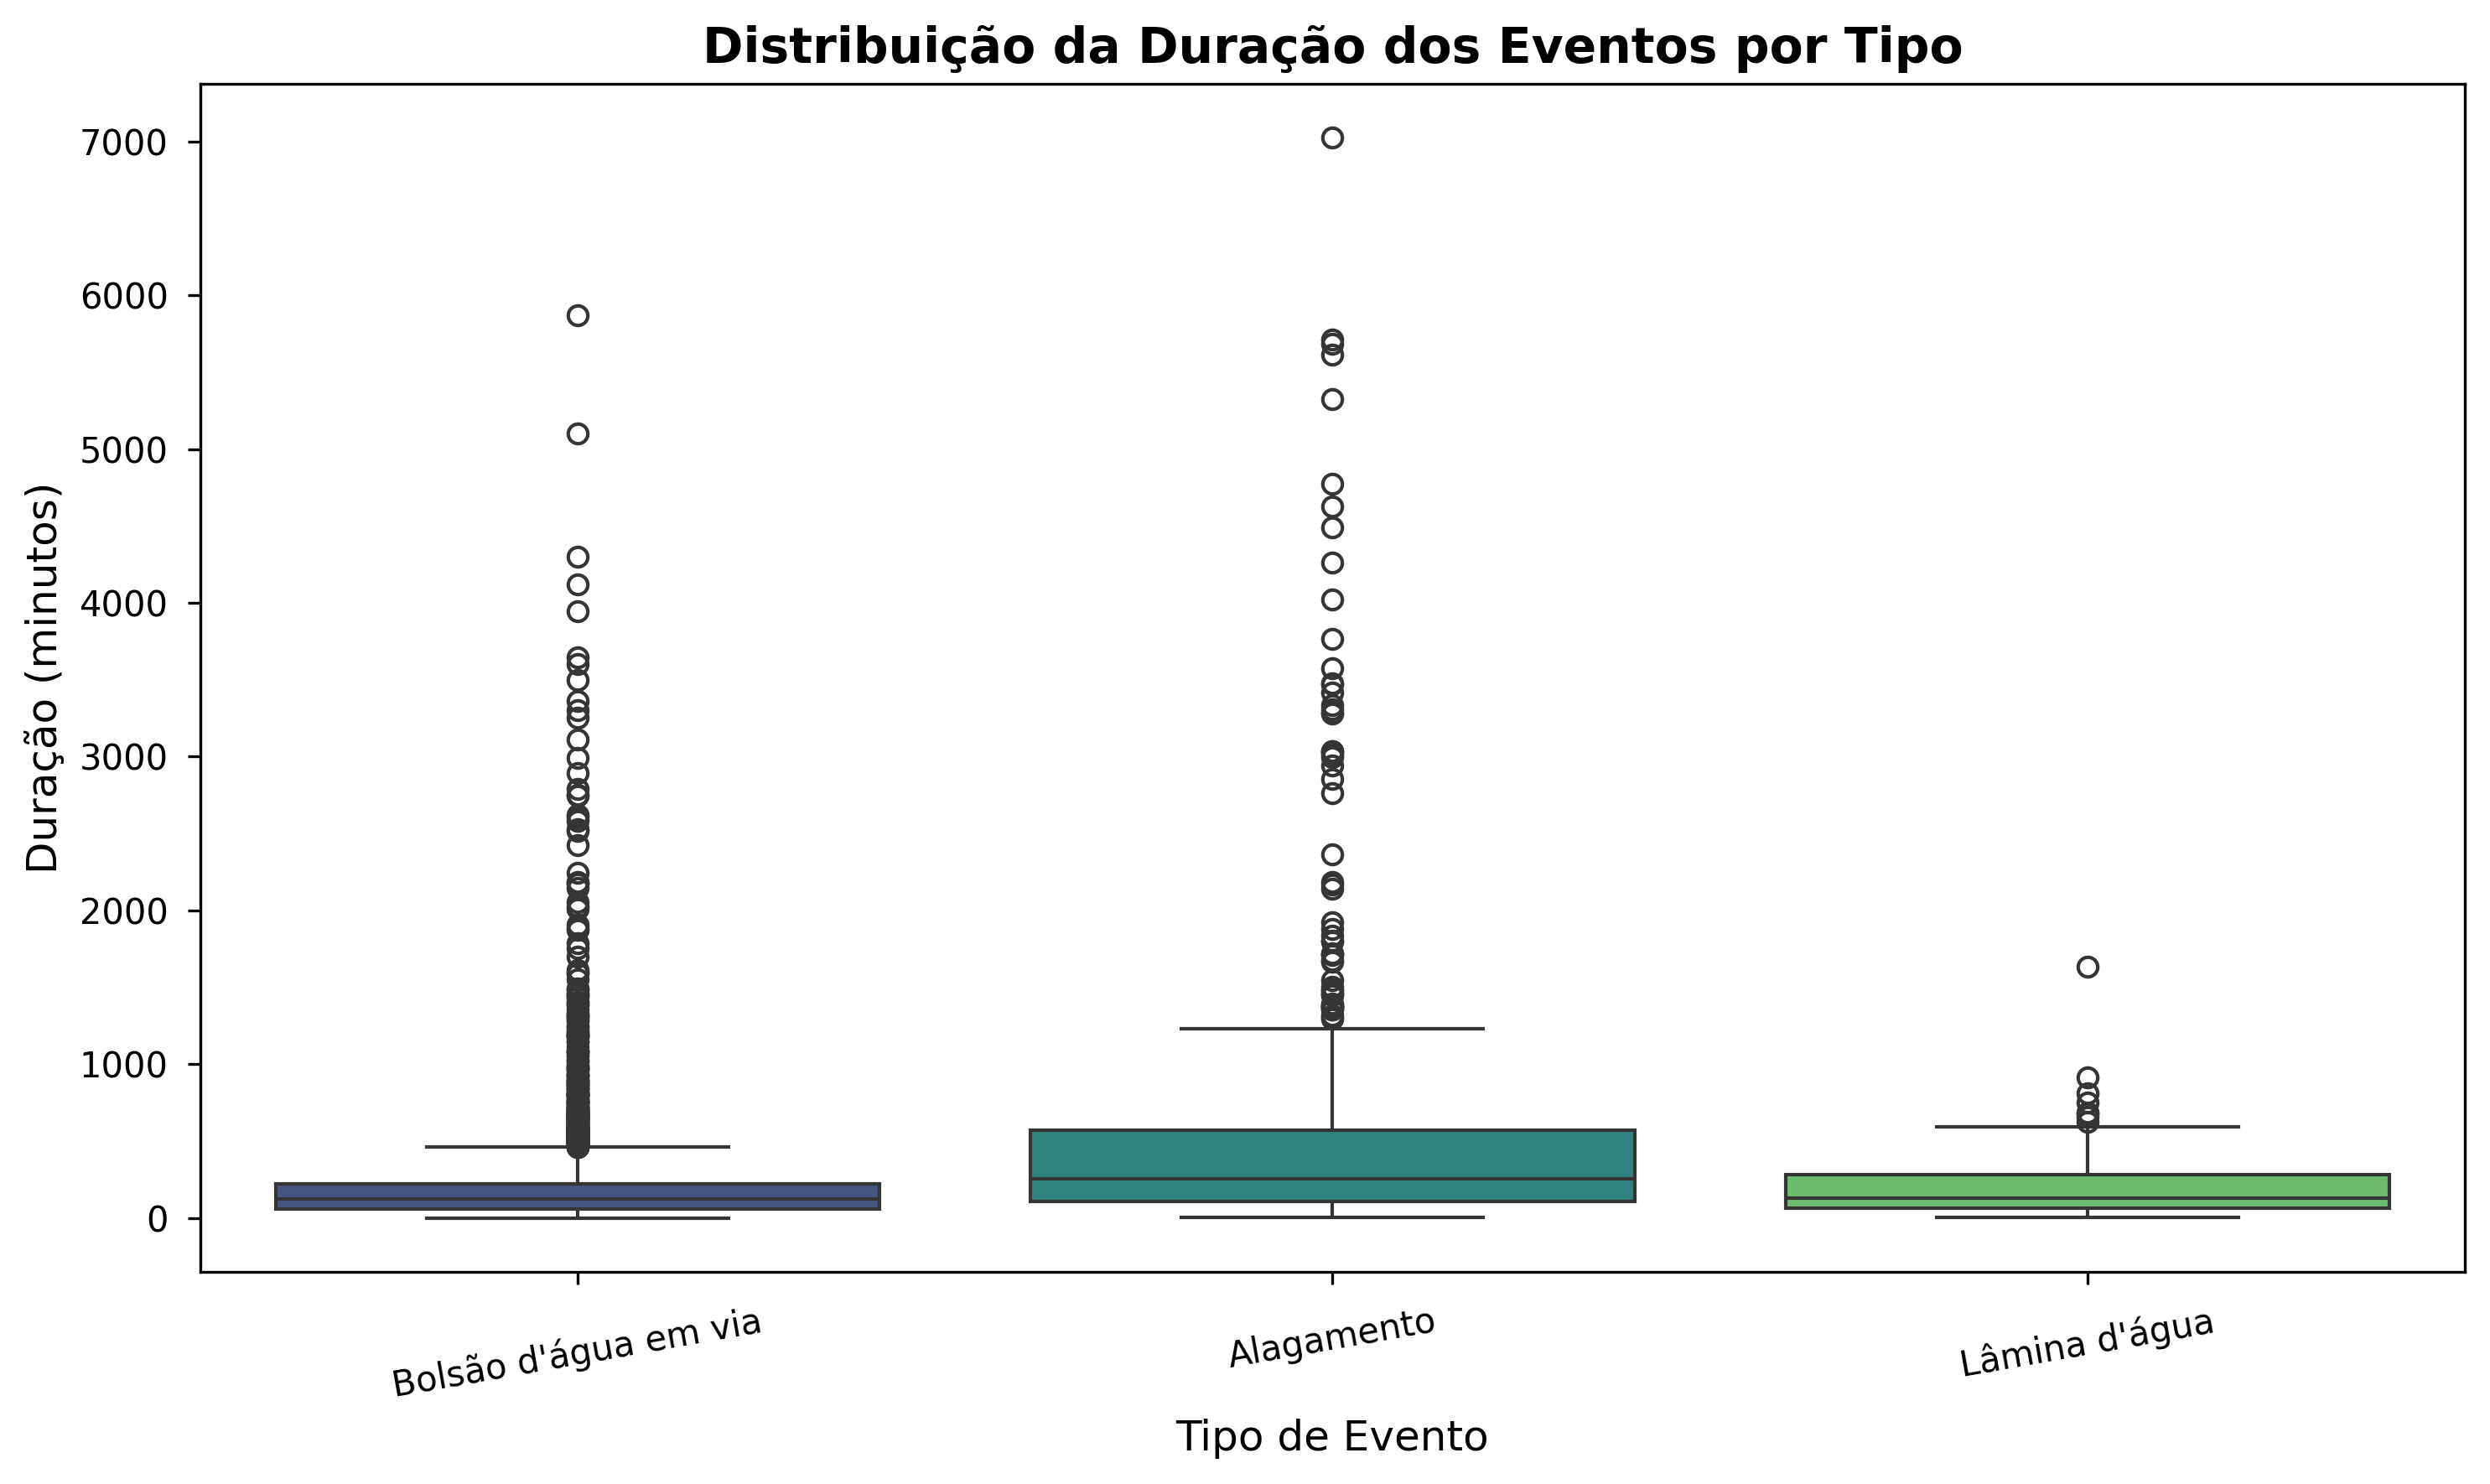

C:\Users\Hanna\AppData\Local\Temp\ipykernel_8112\1996072773.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.boxplot(data=ocorrencias_top_bairros, x='bairro', y='duration_minutes',


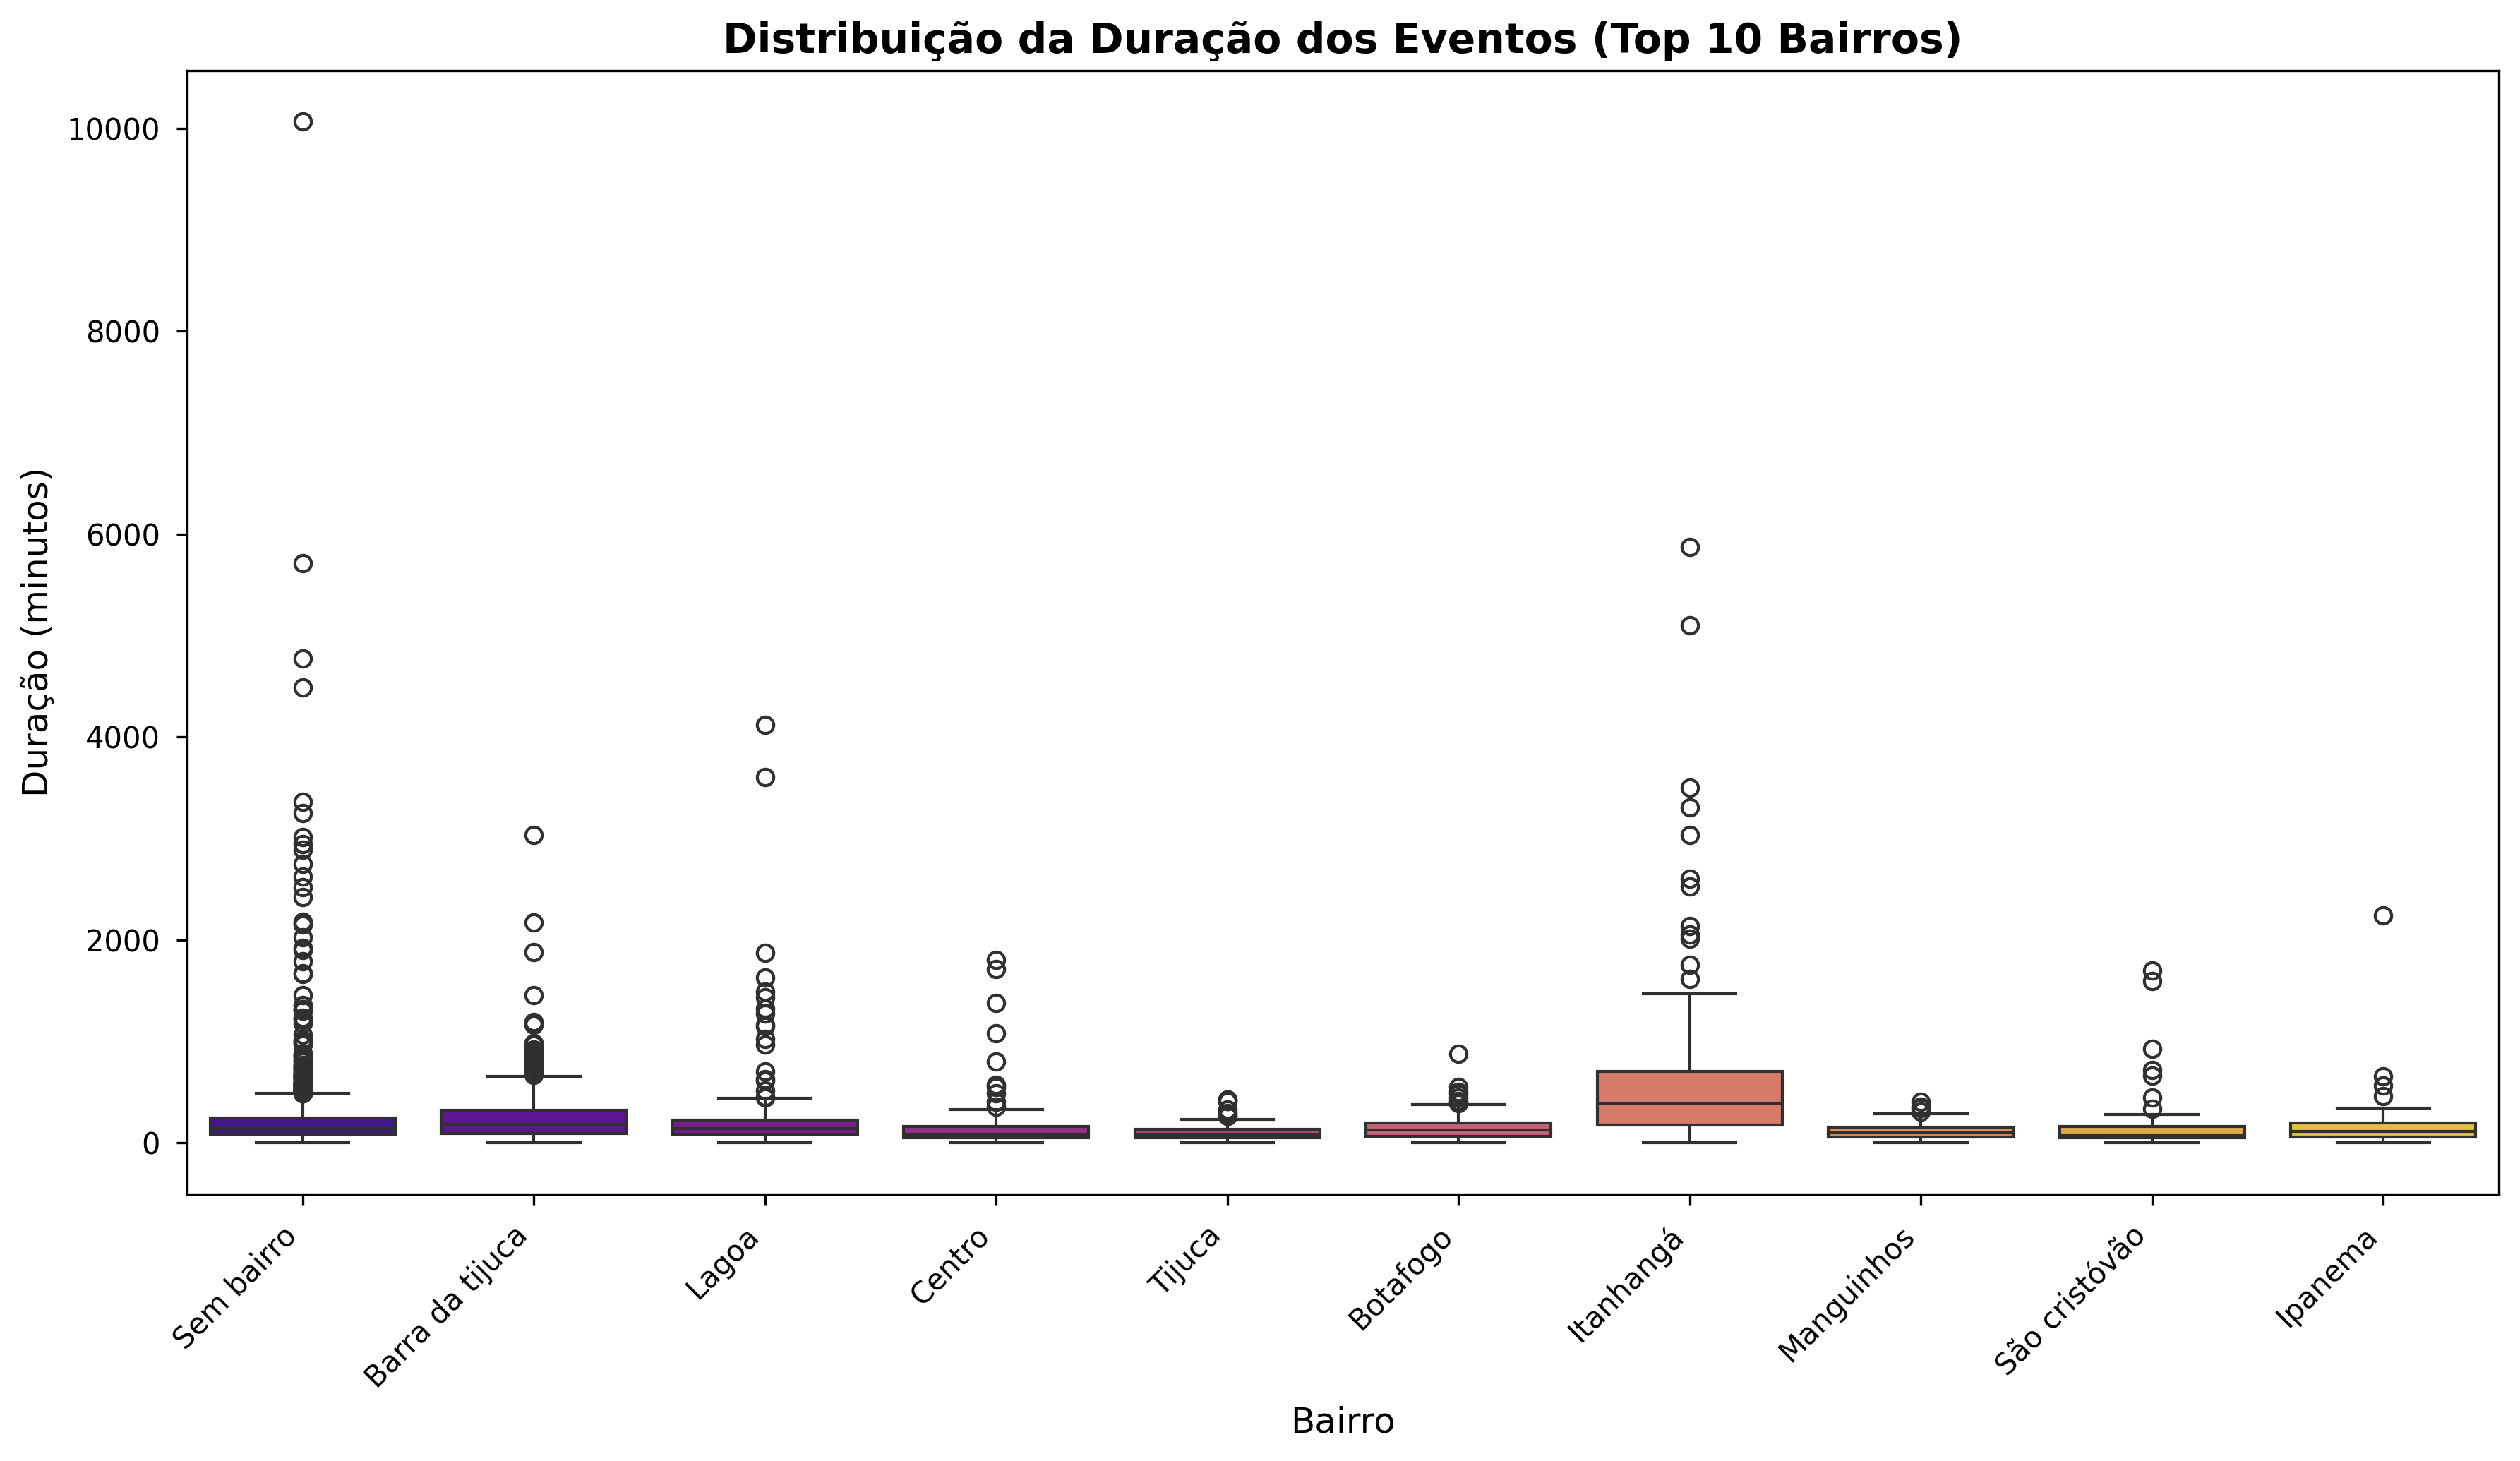

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo e resolução
plt.style.use('seaborn-v0_8-paper')
plt.rcParams['figure.dpi'] = 300

# --- Gráfico 1: Boxplot da Duração por Tipo de Evento ---
# Filtra outliers extremos para melhor visualização, como no original
ocorrencias_filtrado = ocorrencias[ocorrencias['duration_minutes'] < 10000]

plt.figure(figsize=(10, 6))
ax1 = sns.boxplot(data=ocorrencias_filtrado, x='tipo', y='duration_minutes', palette='viridis')
ax1.set_title('Distribuição da Duração dos Eventos por Tipo', fontsize=14, weight='bold')
ax1.set_xlabel('Tipo de Evento', fontsize=12)
ax1.set_ylabel('Duração (minutos)', fontsize=12)
ax1.tick_params(axis='x', labelsize=10)  # Increase x-axis tick label size
ax1.tick_params(axis='y', labelsize=10)  # Increase y-axis tick label size
# Ajusta os rótulos do eixo x para que não se sobreponham
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=10, ha='center')
plt.tight_layout()
plt.show()


# --- Gráfico 2: Boxplot da Duração por Bairro (Top 10) ---
bairro_counts = ocorrencias['bairro'].value_counts().nlargest(10)
top_bairros = bairro_counts.index.tolist()
ocorrencias_top_bairros = ocorrencias[ocorrencias['bairro'].isin(top_bairros)]

plt.figure(figsize=(12, 7))
ax2 = sns.boxplot(data=ocorrencias_top_bairros, x='bairro', y='duration_minutes',
                  order=top_bairros, palette='plasma') # Garante a ordem do maior para o menor
ax2.set_title('Distribuição da Duração dos Eventos (Top 10 Bairros)', fontsize=14, weight='bold')
ax2.set_xlabel('Bairro', fontsize=12)
ax2.set_ylabel('Duração (minutos)', fontsize=12)
ax2.tick_params(axis='x', labelsize=10)  # Increase x-axis tick label size
ax2.tick_params(axis='y', labelsize=10)  # Increase y-axis tick label size
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Pie/Donut Charts

- Percentage share of event types.

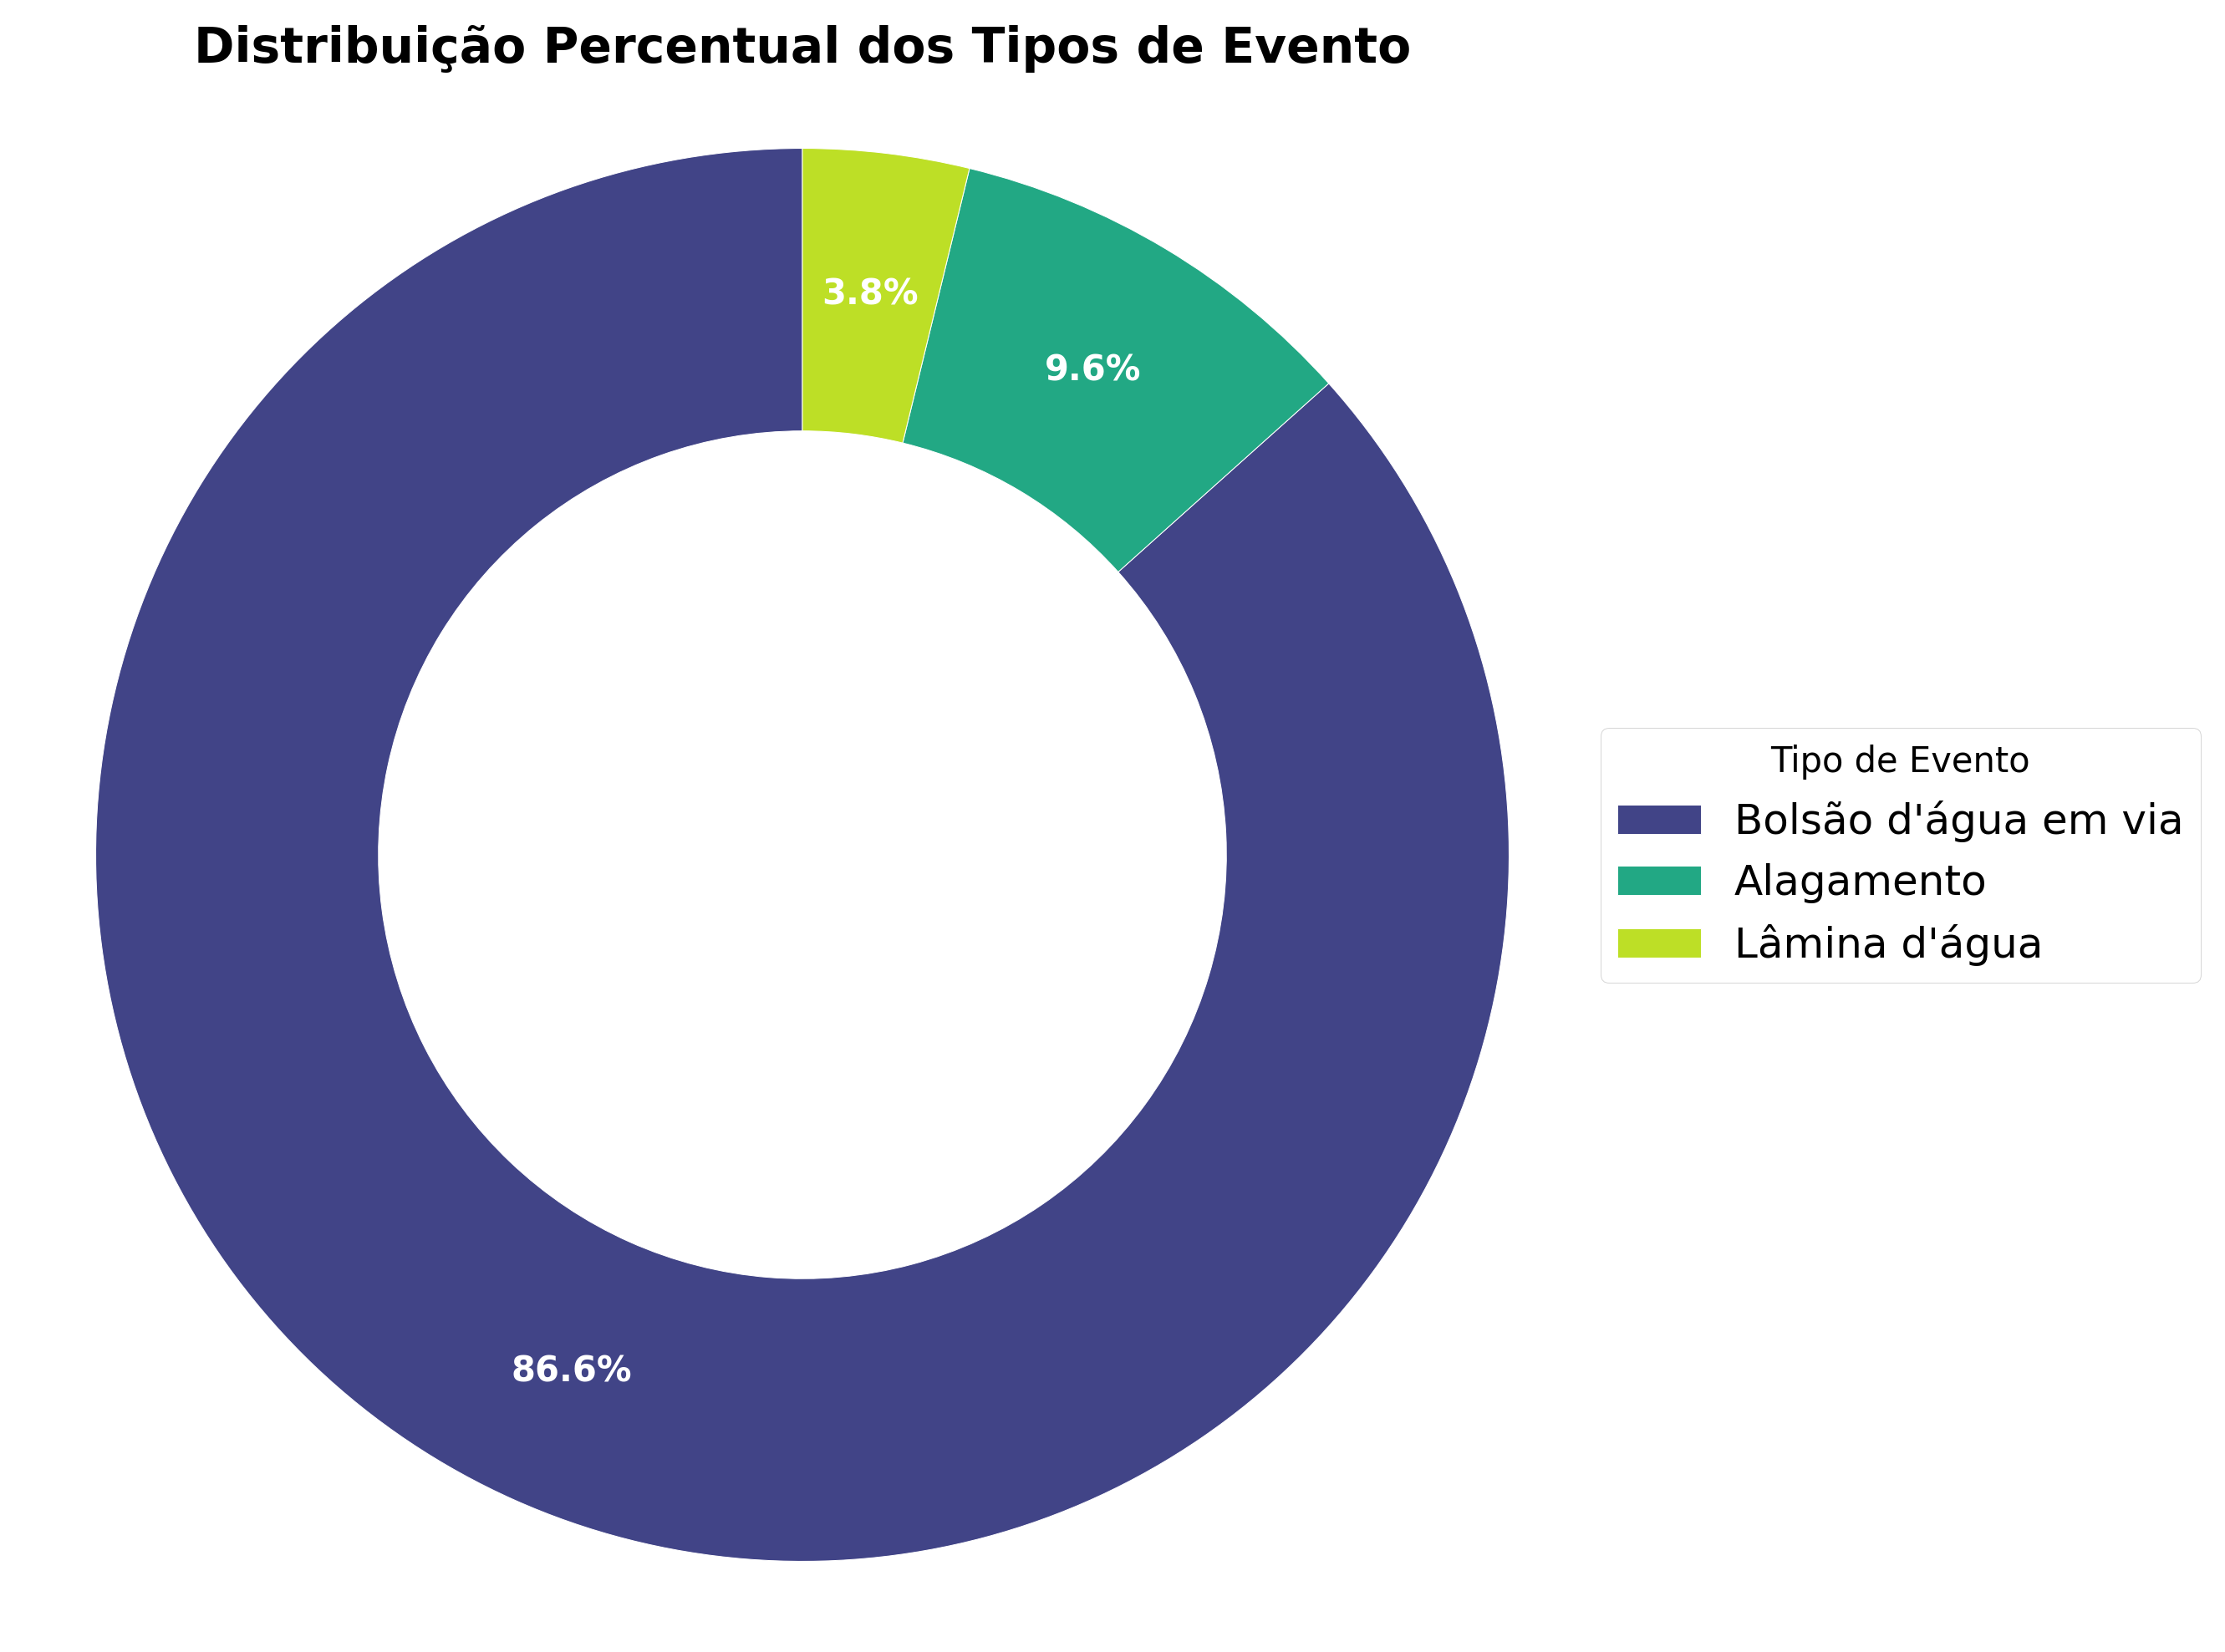

In [31]:
import matplotlib.pyplot as plt

# Estilo e resolução
plt.style.use('seaborn-v0_8-paper')
plt.rcParams['figure.dpi'] = 300

# --- Gráfico de Rosca: Distribuição Percentual dos Tipos de Evento ---
labels = event_type_counts.index
sizes = event_type_counts['count'].values
colors = plt.cm.viridis([0.2, 0.6, 0.9]) # Cores customizadas da paleta viridis

fig, ax = plt.subplots(figsize=(8, 8))
# autopct mostra a porcentagem, startangle rotaciona o início do gráfico
wedges, texts, autotexts = ax.pie(sizes, autopct='%1.1f%%', pctdistance=0.8, startangle=90, colors=colors,
                                  wedgeprops=dict(width=0.4, edgecolor='w'))

# Legenda e título
ax.legend(wedges, labels,
          title="Tipo de Evento",
          loc="center left",
          fontsize=12,
          bbox_to_anchor=(1, 0, 0.5, 1))

plt.setp(autotexts, size=10, weight="bold", color="white")
ax.set_title("Distribuição Percentual dos Tipos de Evento", fontsize=14, weight='bold')

# Garante que o gráfico seja um círculo
ax.axis('equal')
plt.show()

## 4. Advanced & Correlation Visualizations

### Correlation Heatmap

- If you have additional numeric variables, plot a heatmap of correlations.

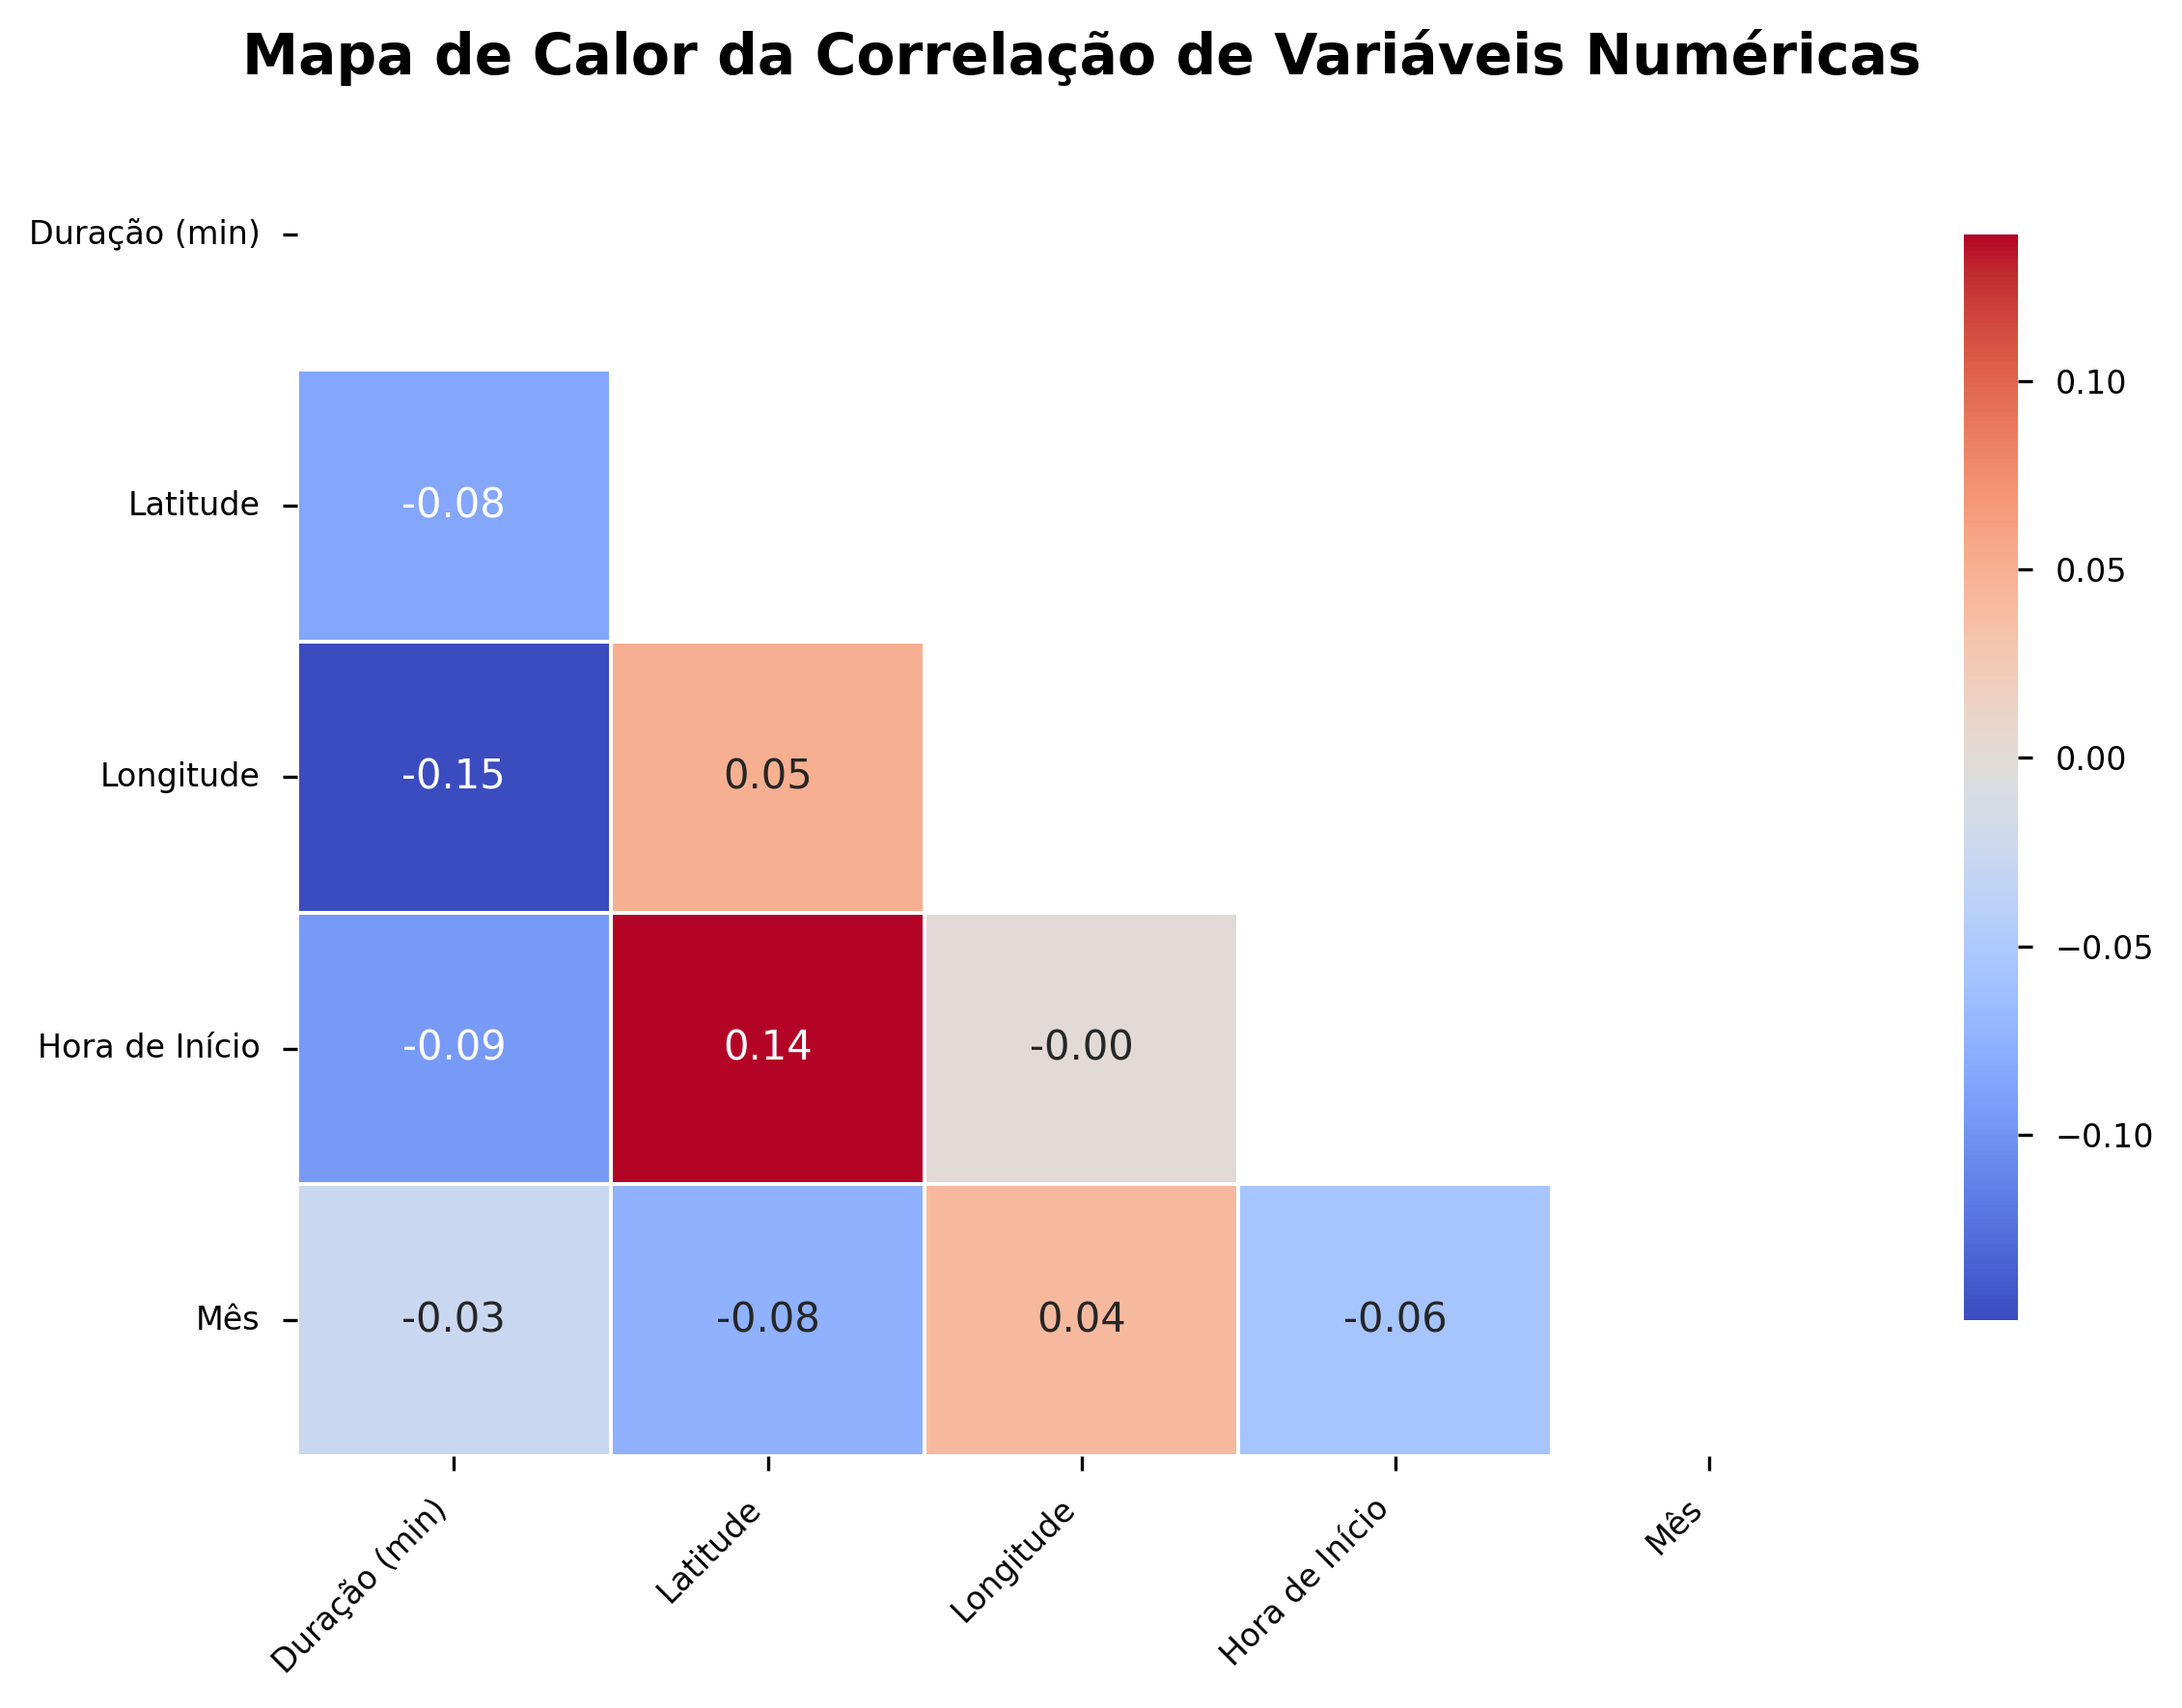

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Estilo e resolução
plt.style.use('seaborn-v0_8-paper')
plt.rcParams['figure.dpi'] = 300

# --- Mapa de Calor de Correlação ---
correlation_matrix = ocorrencias[['duration_minutes', 'latitude', 'longitude', 'hour_start', 'month_num']].corr()

# Renomeia as colunas e índices para português para o gráfico
labels_pt = {
    'duration_minutes': 'Duração (min)',
    'latitude': 'Latitude',
    'longitude': 'Longitude',
    'hour_start': 'Hora de Início',
    'month_num': 'Mês'
}
correlation_matrix.rename(columns=labels_pt, index=labels_pt, inplace=True)

plt.figure(figsize=(8, 6))
# Cria uma máscara para o triângulo superior (opcional, mas comum em publicações)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# annot=True para mostrar os valores, cmap para a paleta de cores
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
            linewidths=.5, cbar_kws={"shrink": .8})

plt.title('Mapa de Calor da Correlação de Variáveis Numéricas', fontsize=14, weight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
# ax.tick_params(axis='x', labelsize=8)  # Increase x-axis tick label size
# ax.tick_params(axis='y', labelsize=8)  # Increase y-axis tick label size
plt.tight_layout()
plt.show()

## 5. Text & Description Analysis

### Word Cloud

- Generate a word cloud from the “descricao” field.

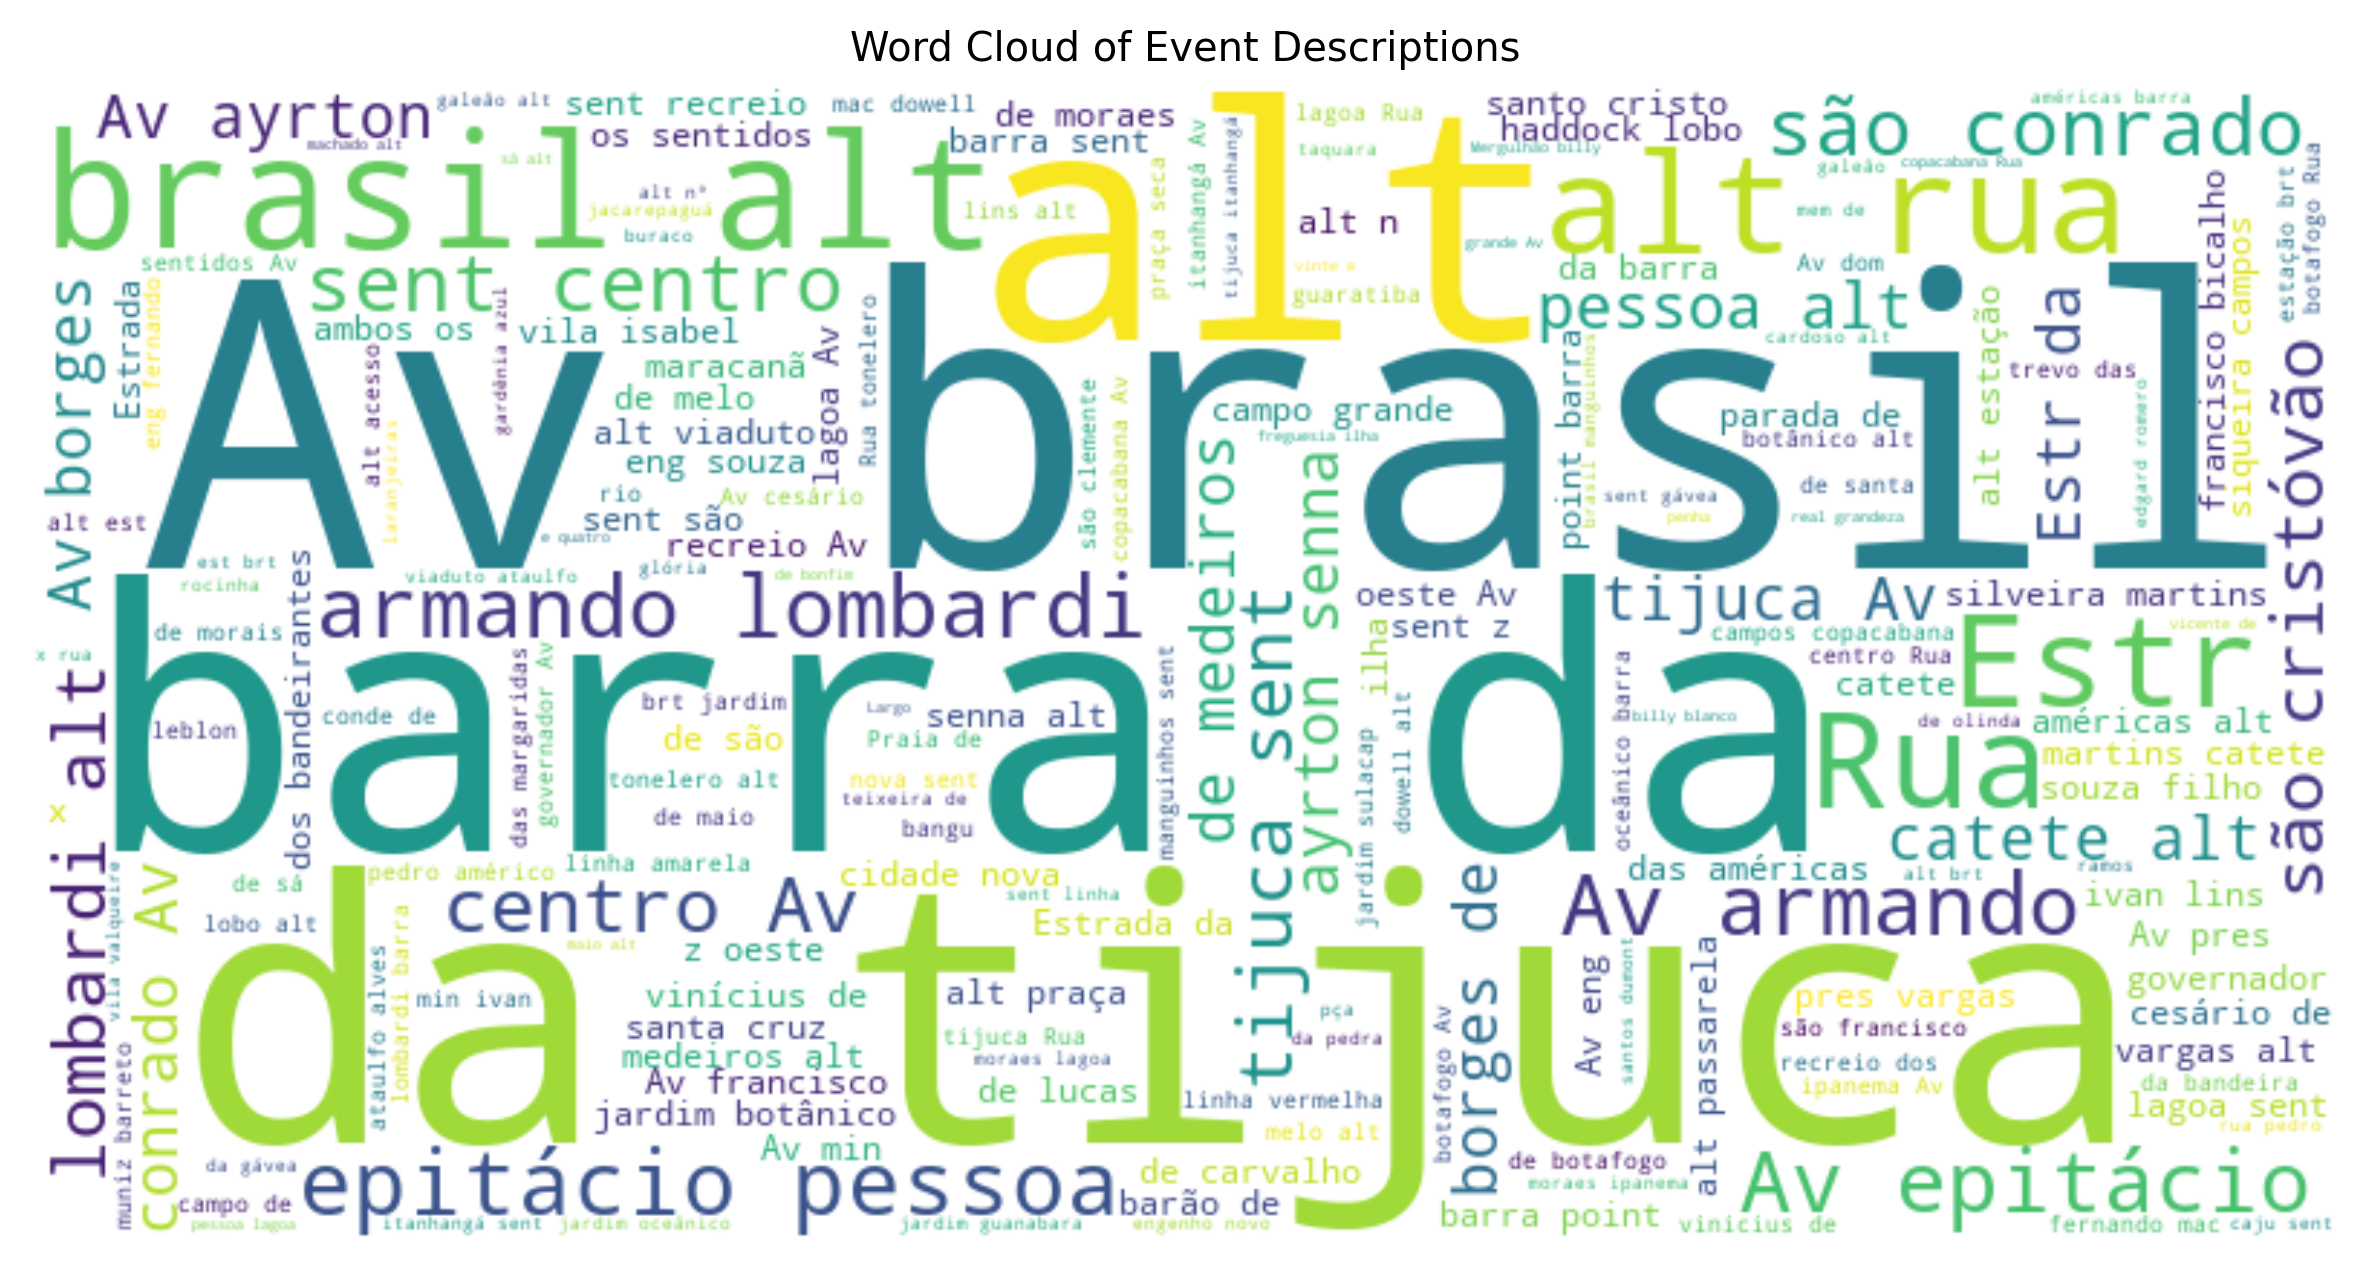

In [33]:
text = " ".join(descricao for descricao in ocorrencias['descricao'].astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title('Word Cloud of Event Descriptions')
# plt.savefig("../charts/word_cloud_event_description.png", dpi=600, bbox_inches='tight')
plt.show()

### Interactive Dashboard Prototypes

- Combining maps, time series, and tables into interactive plots.
- **Note:** For a full interactive dashboard, Plotly Dash would be used, but for this notebook, we're creating interactive plots that can be combined or arranged in a dashboard-like manner. The plots created above are already interactive (zoom, pan, hover data). Further dashboard integration is beyond the scope of this notebook without using Dash.

## 6. Additional Tables & Summaries

### Event Duration vs. Severity Table

- A table comparing average event duration with “gravidade” levels across different bairros.

In [34]:
duration_severity_bairro = ocorrencias.groupby(['bairro', 'gravidade'])['duration_minutes'].mean().unstack(fill_value=0)
print("\n### Event Duration vs. Severity by Bairro")
display(duration_severity_bairro)


### Event Duration vs. Severity by Bairro


gravidade,Alto,Baixo,Critico,Medio,Média,Normal,Sem classificação,Sem_classificacao
bairro,,,,,,,,
Abolição,0.000000,115.516667,0.0,39.400000,0.0,0.000000,0.000000,0.0
Acari,0.000000,1989.853704,0.0,505.111111,0.0,0.000000,0.000000,0.0
Alto da boa vista,1799.466667,60.650000,0.0,0.000000,0.0,0.000000,0.000000,0.0
Anchieta,0.000000,640.540196,0.0,962.300000,0.0,0.000000,110.516667,0.0
Andaraí,0.000000,72.228571,0.0,81.733333,0.0,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...
Vila isabel,69.800000,71.293056,0.0,107.766667,0.0,60.000000,0.000000,0.0
Vila kosmos,0.000000,22.916667,0.0,0.000000,0.0,0.000000,0.000000,0.0
Vila militar,0.000000,148.895833,0.0,0.000000,0.0,0.000000,0.000000,0.0


### Status and Prazo Summaries

- Small tables summarizing the count of events by “status” and “prazo” categories.

In [35]:
print("\n### Status Summary Table")
display(status_counts)

print("\n### Prazo Summary Table")
display(prazo_counts.to_frame())


### Status Summary Table


,count
status,
Fechado,4864
Aberto,4



### Prazo Summary Table


,count
prazo,
Curto,3025
Desconhecido,1836
Medio,5
Longo,2


---

This Jupyter Notebook provides a comprehensive set of visualizations and tables to analyze the flood event dataset. Each section corresponds to the visualization plan, offering insights into temporal trends, spatial distributions, categorical breakdowns, and textual analysis of event descriptions. The interactive nature of Plotly visualizations allows for deeper exploration of the data.